In [1]:
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


In [2]:
!pip install ultralytics opencv-python matplotlib pyyaml tqdm xmltodict

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 46.9/46.9 kB 3.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 30.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 96.0/96.0 kB 11.0 MB/s eta 0:00:00


In [15]:
import os
import shutil
import random
import glob
from pathlib import Path
import yaml
import cv2
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
from tqdm.notebook import tqdm
from sklearn.model_selection import train_test_split
from ultralytics import YOLO
from google.colab import drive
import xmltodict

Creating new Ultralytics Settings v0.0.8 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/usage/settings.


In [16]:
import torch
RANDOM_SEED = 42
random.seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)
torch.manual_seed(RANDOM_SEED)

In [17]:

import yaml

# --- Main Configuration ---
# 1. Path to the main folder for your CRATER dataset
CRATER_DATASET_PATH = "/content/drive/MyDrive/Major Project/Manual_dataset/crater_dataset"

# 2. Path to the main folder for your BOULDER dataset
BOULDER_DATASET_PATH = "/content/drive/MyDrive/Major Project/Manual_dataset/boulder_dataset"


def create_yolo_configs_for_separate_models():
    """
    Creates two separate data.yaml files in their respective dataset folders,
    one for the crater model and one for the boulder model.
    """
    print("Creating separate data.yaml configuration files for separate directories...")

    # --- 1. Create crater_data.yaml ---
    # It will be saved inside your CRATER_DATASET_PATH
    crater_yaml_config = {
        'path': CRATER_DATASET_PATH,
        'train': os.path.join(CRATER_DATASET_PATH, 'train', 'images'),
        'val': os.path.join(CRATER_DATASET_PATH, 'val', 'images'),
        # 'test' path is removed as per your request for the crater dataset
        'names': {0: 'crater'},
        'nc': 1  # Number of classes is 1
    }
    crater_yaml_path = os.path.join(CRATER_DATASET_PATH, 'crater_data.yaml')
    with open(crater_yaml_path, 'w') as f:
        yaml.dump(crater_yaml_config, f, sort_keys=False)
    print(f"Crater configuration saved successfully to: {crater_yaml_path}")


    # --- 2. Create boulder_data.yaml ---
    # It will be saved inside your BOULDER_DATASET_PATH
    boulder_yaml_config = {
        'path': BOULDER_DATASET_PATH,
        'train': os.path.join(BOULDER_DATASET_PATH, 'train', 'images'),
        'val': os.path.join(BOULDER_DATASET_PATH, 'val', 'images'),
        'test': os.path.join(BOULDER_DATASET_PATH, 'test', 'images'),
        'names': {0: 'boulder'}, # For this model, boulder is class 0
        'nc': 1                  # Number of classes is 1
    }
    boulder_yaml_path = os.path.join(BOULDER_DATASET_PATH, 'boulder_data.yaml')
    with open(boulder_yaml_path, 'w') as f:
        yaml.dump(boulder_yaml_config, f, sort_keys=False)
    print(f"Boulder configuration saved successfully to: {boulder_yaml_path}")




In [ ]:
# --- Run the function ---
# This will create 'crater_data.yaml' in the crater folder and 'boulder_data.yaml' in the boulder folder.
create_yolo_configs_for_separate_models()

Creating separate data.yaml configuration files for separate directories...
Crater configuration saved successfully to: /content/drive/MyDrive/Major Project/Manual_dataset/crater_dataset/crater_data.yaml
Boulder configuration saved successfully to: /content/drive/MyDrive/Major Project/Manual_dataset/boulder_dataset/boulder_data.yaml


✅ Found 10243 images


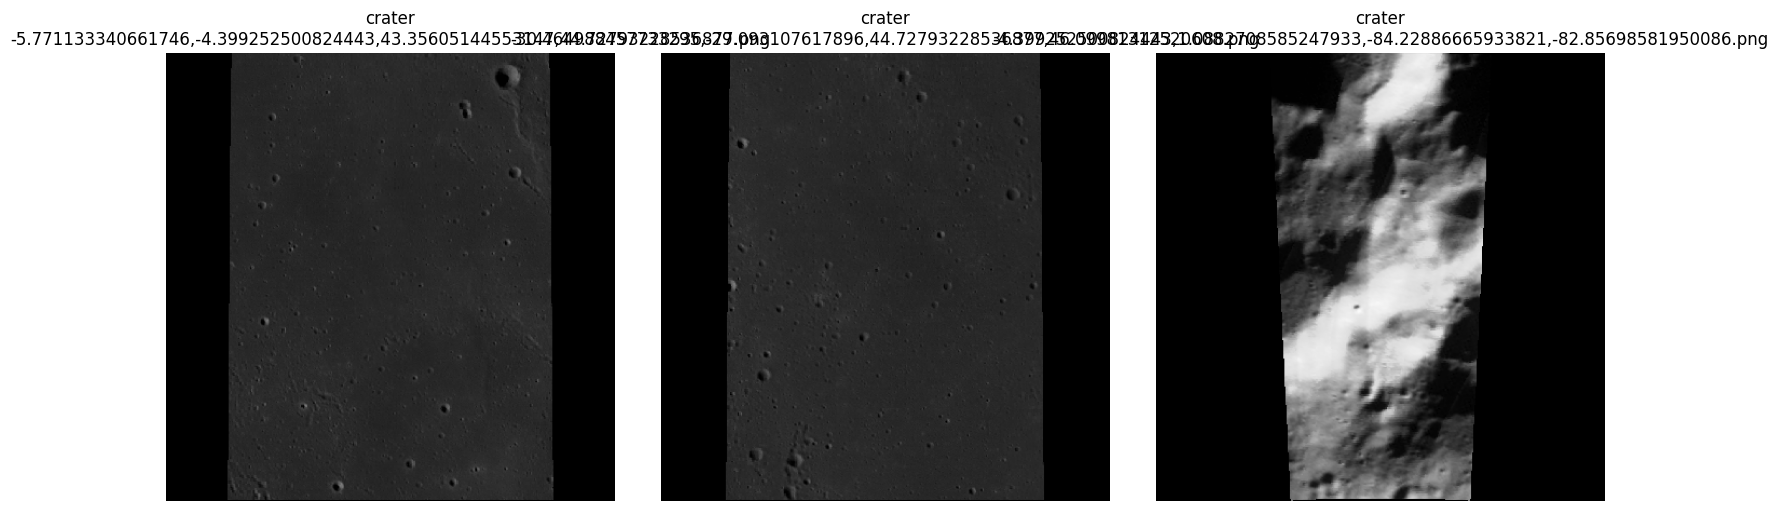

✅ Found 5802 images


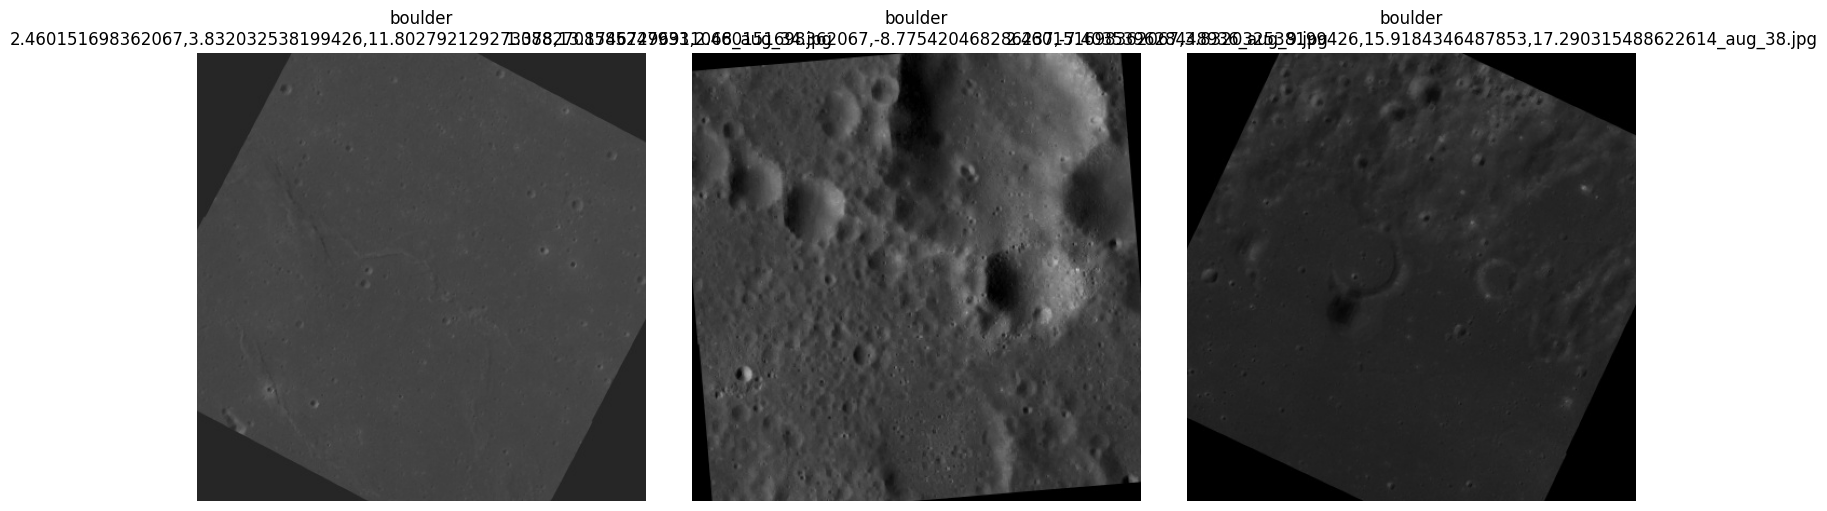

In [ ]:
import os
import matplotlib.pyplot as plt
from PIL import Image

def visualize_single_dataset(dataset_path, class_name='crater', num_samples=3):
    image_files = []

    # Find all image files
    for root, dirs, files in os.walk(dataset_path):
        for file in files:
            if file.lower().endswith(('.jpg', '.jpeg', '.png', '.bmp', '.tif', '.tiff')):
                image_files.append(os.path.join(root, file))

    # Check if images were found
    if len(image_files) == 0:
        print("❌ No images found in:", dataset_path)
        return

    print(f"✅ Found {len(image_files)} images")

    # Don't request more images than available
    num_samples = min(num_samples, len(image_files))

    # Display images
    plt.figure(figsize=(15, 5))

    for i in range(num_samples):
        img = Image.open(image_files[i])

        plt.subplot(1, num_samples, i + 1)
        plt.imshow(img, cmap='gray')
        plt.title(f"{class_name}\n{os.path.basename(image_files[i])}")
        plt.axis('off')

    plt.tight_layout()
    plt.show()


# -------------------------------
# Visualize CRATER dataset
# -------------------------------
visualize_single_dataset(
    CRATER_DATASET_PATH,
    class_name='crater',
    num_samples=3
)


# -------------------------------
# Visualize BOULDER dataset
# -------------------------------
visualize_single_dataset(
    BOULDER_DATASET_PATH,
    class_name='boulder',
    num_samples=3
)

In [4]:

def visualize_single_dataset(dataset_path, class_name, num_samples=5):
    """
    Visualize random samples from a single-class dataset.

    Args:
        dataset_path (str): The root path to the specific dataset (e.g., your crater dataset).
        class_name (str): The name of the class for this dataset (e.g., 'crater').
        num_samples (int): How many random images to show.
    """
    print(f"Visualizing {num_samples} samples for class: '{class_name}'")

    # Define class name and color for this specific dataset
    CLASS_NAMES = {0: class_name}
    COLOR = (0, 255, 0) # Green for all boxes

    train_images_path = os.path.join(dataset_path, "train", "images")
    train_labels_path = os.path.join(dataset_path, "train", "labels")

    image_files = glob.glob(os.path.join(train_images_path, "*.jpg")) + \
                  glob.glob(os.path.join(train_images_path, "*.png"))

    if not image_files:
        print(f"No images found in '{train_images_path}'. Please check the path.")
        return

    samples = random.sample(image_files, min(num_samples, len(image_files)))

    plt.figure(figsize=(20, 6 * num_samples))
    for i, img_path in enumerate(samples):
        img = cv2.imread(img_path)
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        h, w, _ = img.shape

        base_name = os.path.splitext(os.path.basename(img_path))[0]
        label_path = os.path.join(train_labels_path, f"{base_name}.txt")

        if os.path.exists(label_path):
            with open(label_path, 'r') as f:
                for line in f:
                    parts = line.strip().split()
                    cls_id = int(parts[0])
                    x_center, y_center, width, height = map(float, parts[1:5])

                    x1 = int((x_center - width/2) * w)
                    y1 = int((y_center - height/2) * h)
                    x2 = int((x_center + width/2) * w)
                    y2 = int((y_center + height/2) * h)

                    # Get the class name from the dictionary (will always be class 0 now)
                    name_to_display = CLASS_NAMES.get(cls_id, 'Unknown')

                    cv2.rectangle(img, (x1, y1), (x2, y2), COLOR, 2)
                    cv2.putText(img, name_to_display, (x1, y1 - 10), cv2.FONT_HERSHEY_SIMPLEX, 0.7, COLOR, 2)

        plt.subplot(num_samples, 1, i + 1)
        plt.imshow(img)
        plt.title(f"Sample: {os.path.basename(img_path)}")
        plt.axis('off')

    plt.tight_layout()
    plt.show()

Visualizing 3 samples for class: 'crater'


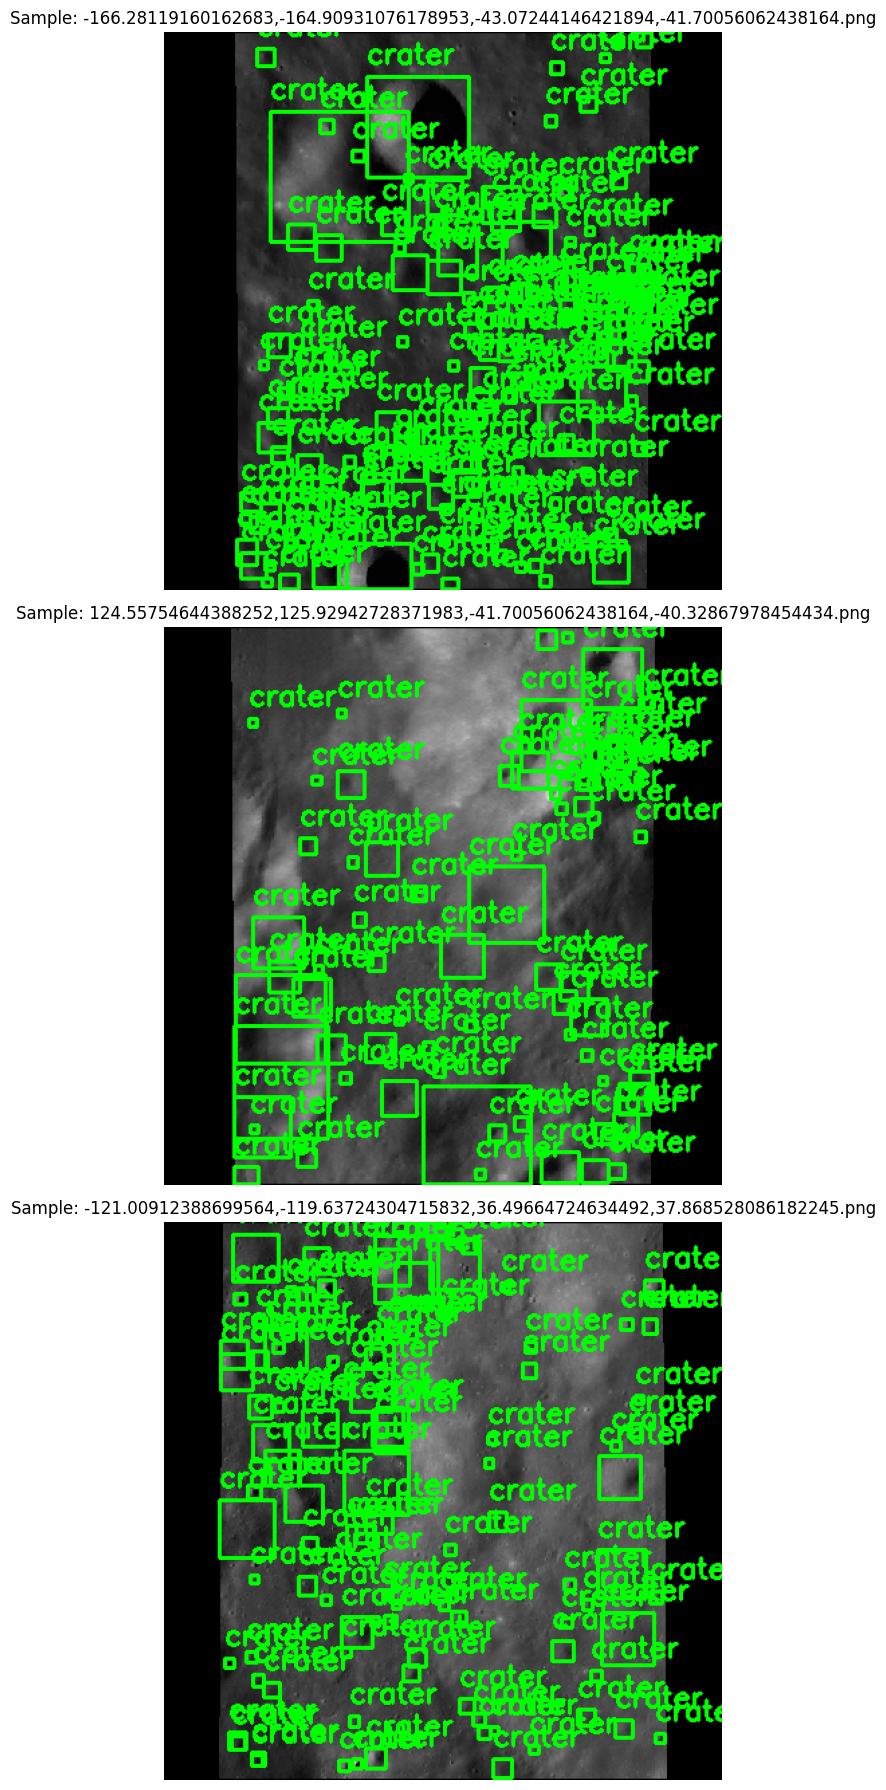

In [ ]:
CRATER_DATASET_PATH = "/content/drive/MyDrive/Major Project/Manual_dataset/crater_dataset"

visualize_single_dataset(
    CRATER_DATASET_PATH,
    class_name='crater',
    num_samples=3
)

Visualizing 3 samples for class: 'boulder'


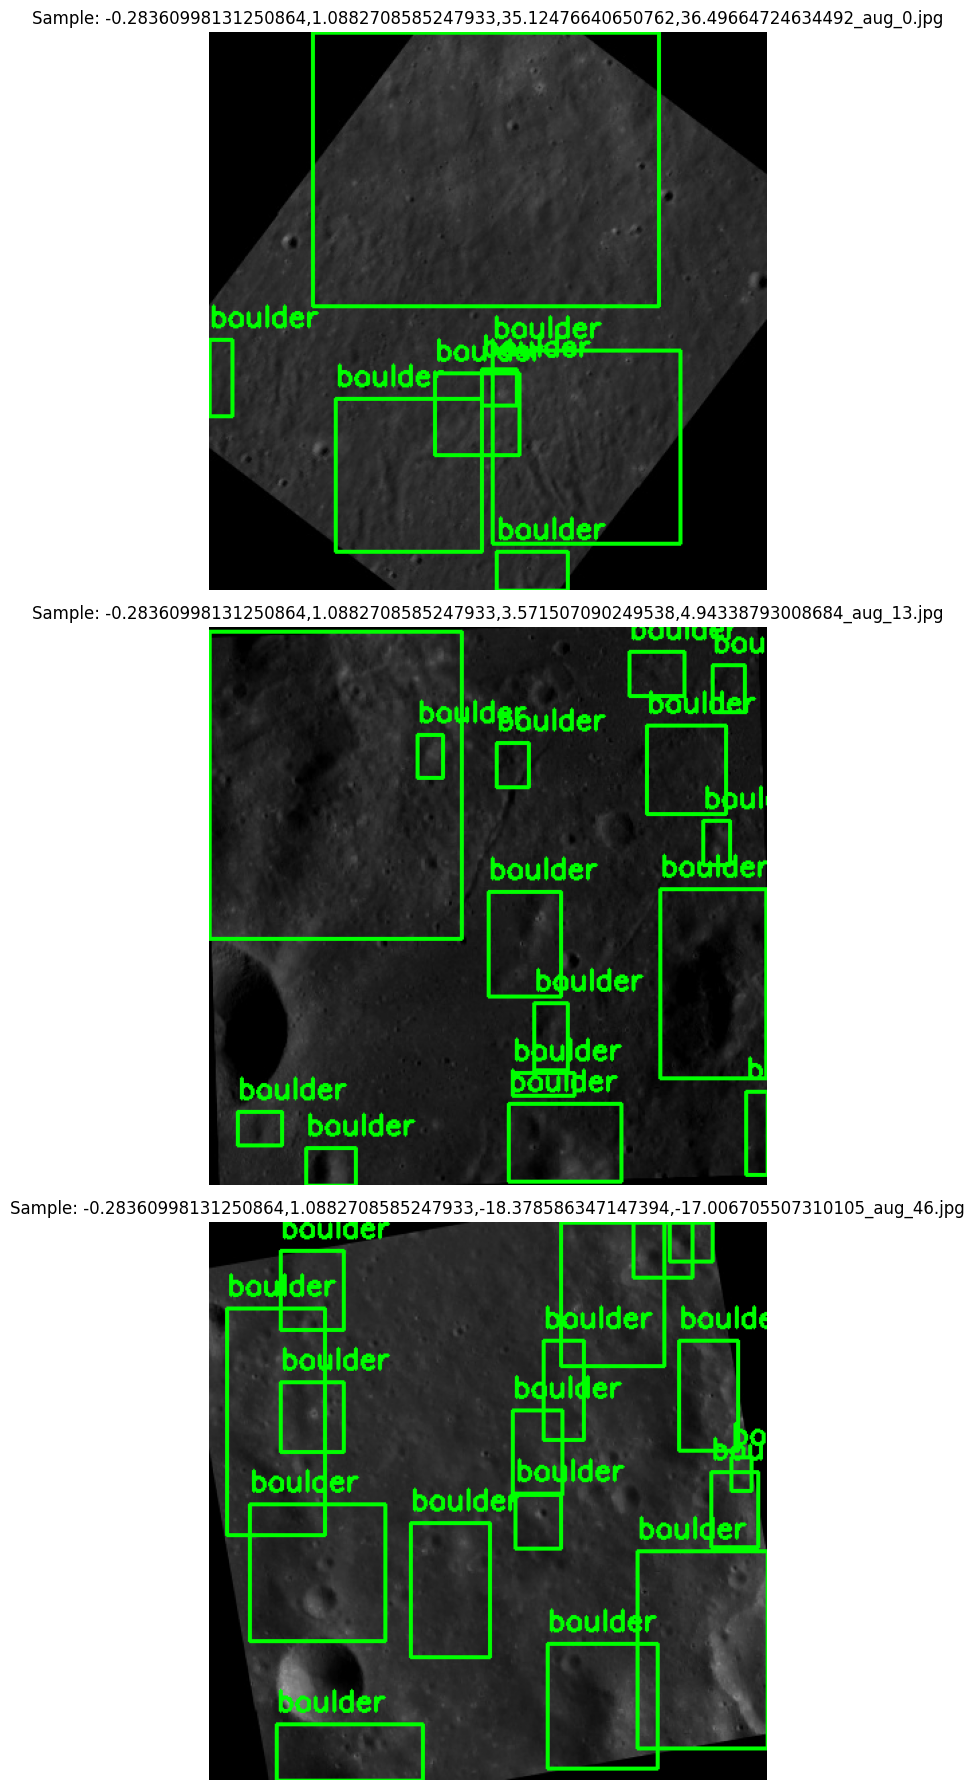

In [ ]:
BOULDER_DATASET_PATH = "/content/drive/MyDrive/Major Project/Manual_dataset/boulder_dataset"
visualize_single_dataset(BOULDER_DATASET_PATH, class_name='boulder', num_samples=3)

In [ ]:
MODEL_SAVE_DIR = "/content/drive/MyDrive/Major Project/Manual_dataset/My_Lunar_Models"
os.makedirs(MODEL_SAVE_DIR, exist_ok=True)
print(f"Models will be saved to: {MODEL_SAVE_DIR}")


Models will be saved to: /content/drive/MyDrive/Major Project/Manual_dataset/My_Lunar_Models


In [ ]:
def train_model(data_yaml_path, project_name, epochs=5, img_size=640, batch_size=16, pretrained_weights='yolov8s.pt'):
    """
    Initializes and trains a YOLOv8 model with specific regularization and augmentation settings.
    """
    print("--------------------------------------------------")
    print(f"Starting training for: {project_name}")
    print(f"Using data from: {data_yaml_path}")
    print(f"Training for {epochs} epochs...")
    print("--------------------------------------------------")

    # Initialize YOLOv8 model
    model = YOLO(pretrained_weights)

    # Train the model
    results = model.train(
        data=data_yaml_path,
        epochs=epochs,
        imgsz=img_size,
        batch=batch_size,
        name=project_name,
        cache=False,
        workers=2,
        device=0 if torch.cuda.is_available() else 'cpu',
        project='/content/lunar_crater_runs',
        patience=20,
        save_period=10,
        cos_lr=True,
        weight_decay=0.0005,
        augment=True,
        mixup=0.1,
        mosaic=1.0,
        degrees=0.2,
        translate=0.1,
        scale=0.5,
        fliplr=0.5,
        flipud=0.5
    )

    print(f"\nTraining complete for {project_name}!")
    return model, results


In [18]:
import torch

print("CUDA available:", torch.cuda.is_available())
print("CUDA version:", torch.version.cuda)

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

CUDA available: True
CUDA version: 13.0
GPU: Tesla T4


In [ ]:
CRATER_PROJECT_NAME = "lunar_crater_model"
CRATER_YAML_PATH = "/content/drive/MyDrive/Major Project/Manual_dataset/crater_dataset/crater_data.yaml"

crater_model, crater_training_results = train_model(
    data_yaml_path=CRATER_YAML_PATH,
    project_name=CRATER_PROJECT_NAME,
    epochs=10,
    img_size=512,
    batch_size=8,
    pretrained_weights='yolov8s.pt'
)

--------------------------------------------------
Starting training for: lunar_crater_model
Using data from: /content/drive/MyDrive/Major Project/Manual_dataset/crater_dataset/crater_data.yaml
Training for 10 epochs...
--------------------------------------------------
Ultralytics 8.4.126 🚀 Python-3.13.15 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=True, auto_augment=randaugment, batch=8, bgr=0.0, box=7.5, cache=False, cfg=None, channels_last=False, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, cls_remap=True, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=True, cutmix=0.0, data=/content/drive/MyDrive/Major Project/Manual_dataset/crater_dataset/crater_data.yaml, degrees=0.2, deterministic=True, device=0, dfl=1.5, dgrad=0.5, dis=6.0, distill_model=None, dlam=1.0, dlog=1.0, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=10, erasing=0.4, exist_ok=False, fliplr=0.5, f

In [ ]:

CRATER_PROJECT_NAME = "lunar_crater_model"
BEST_CRATER_MODEL_PATH = f"/content/lunar_crater_runs/{CRATER_PROJECT_NAME}/weights/best.pt"
DRIVE_CRATER_MODEL_PATH = os.path.join(MODEL_SAVE_DIR, "crater_best.pt")

if os.path.exists(BEST_CRATER_MODEL_PATH):
    shutil.copy2(BEST_CRATER_MODEL_PATH, DRIVE_CRATER_MODEL_PATH)
    print(f"Crater model successfully saved to: {DRIVE_CRATER_MODEL_PATH}")
else:
    print(f"Could not find best crater model at: {BEST_CRATER_MODEL_PATH}")

Crater model successfully saved to: /content/drive/MyDrive/Major Project/Manual_dataset/My_Lunar_Models/crater_best.pt


Total images: 10

image 1/1 /content/drive/MyDrive/Major Project/Manual_dataset/crater_dataset/test/images/-72.99329449268984,-71.62141365285257,-15.634824667472792,-14.262943827635459.png: 512x512 106 craters, 11.1ms
Speed: 72.9ms preprocess, 11.1ms inference, 41.6ms postprocess per image at shape (1, 3, 512, 512)
Image 1: -72.99329449268984,-71.62141365285257,-15.634824667472792,-14.262943827635459.png
Craters detected: 106


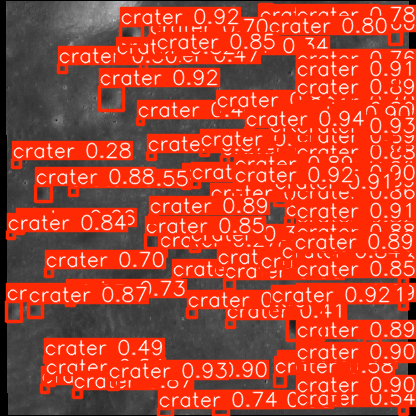


image 1/1 /content/drive/MyDrive/Major Project/Manual_dataset/crater_dataset/test/images/-66.13389029350333,-64.762009453666,-47.188083983730884,-45.816203143893574.png: 512x512 109 craters, 11.0ms
Speed: 2.2ms preprocess, 11.0ms inference, 1.5ms postprocess per image at shape (1, 3, 512, 512)
Image 2: -66.13389029350333,-64.762009453666,-47.188083983730884,-45.816203143893574.png
Craters detected: 109


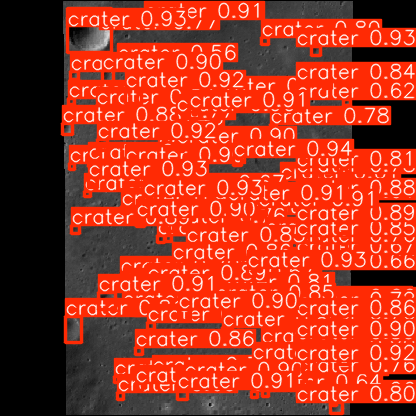


image 1/1 /content/drive/MyDrive/Major Project/Manual_dataset/crater_dataset/test/images/-67.50577113334063,-66.13389029350333,-37.58491810486972,-36.213037265032405.png: 512x512 81 craters, 11.1ms
Speed: 3.7ms preprocess, 11.1ms inference, 2.0ms postprocess per image at shape (1, 3, 512, 512)
Image 3: -67.50577113334063,-66.13389029350333,-37.58491810486972,-36.213037265032405.png
Craters detected: 81


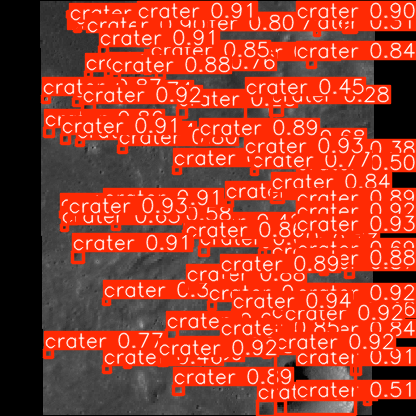


image 1/1 /content/drive/MyDrive/Major Project/Manual_dataset/crater_dataset/test/images/-81.22457953171372,-78.4808178520391,72.16554908211495,73.53742992195225.png: 512x512 112 craters, 11.0ms
Speed: 2.0ms preprocess, 11.0ms inference, 1.5ms postprocess per image at shape (1, 3, 512, 512)
Image 4: -81.22457953171372,-78.4808178520391,72.16554908211495,73.53742992195225.png
Craters detected: 112


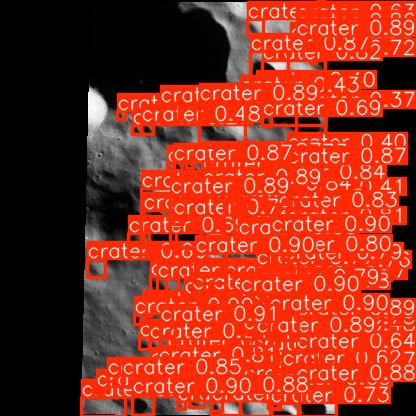


image 1/1 /content/drive/MyDrive/Major Project/Manual_dataset/crater_dataset/test/images/-83.96834121138832,-82.59646037155102,-8.775420468286237,-7.403539628448936.png: 512x512 62 craters, 11.0ms
Speed: 2.0ms preprocess, 11.0ms inference, 1.5ms postprocess per image at shape (1, 3, 512, 512)
Image 5: -83.96834121138832,-82.59646037155102,-8.775420468286237,-7.403539628448936.png
Craters detected: 62


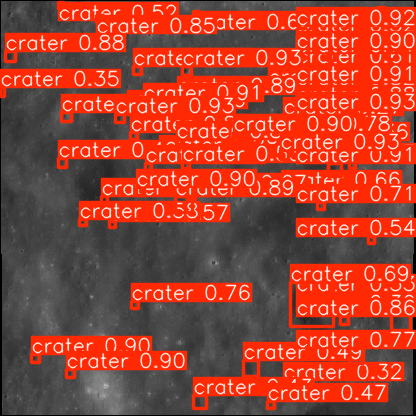


image 1/1 /content/drive/MyDrive/Major Project/Manual_dataset/crater_dataset/test/images/-78.4808178520391,-75.73705617236449,77.65307244146418,79.02495328130148.png: 512x512 75 craters, 11.0ms
Speed: 2.0ms preprocess, 11.0ms inference, 1.5ms postprocess per image at shape (1, 3, 512, 512)
Image 6: -78.4808178520391,-75.73705617236449,77.65307244146418,79.02495328130148.png
Craters detected: 75


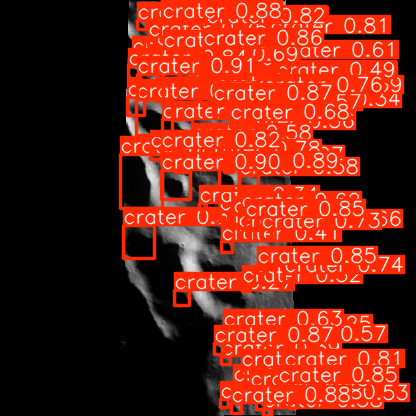


image 1/1 /content/drive/MyDrive/Major Project/Manual_dataset/crater_dataset/test/images/-79.85269869187638,-78.4808178520391,-48.55996482356818,-47.188083983730884.png: 512x512 110 craters, 11.0ms
Speed: 2.0ms preprocess, 11.0ms inference, 1.9ms postprocess per image at shape (1, 3, 512, 512)
Image 7: -79.85269869187638,-78.4808178520391,-48.55996482356818,-47.188083983730884.png
Craters detected: 110


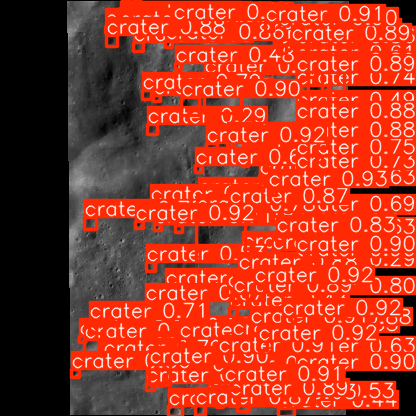


image 1/1 /content/drive/MyDrive/Major Project/Manual_dataset/crater_dataset/test/images/-92.19962625041217,-90.82774541057486,-38.95679894470701,-37.58491810486972.png: 512x512 41 craters, 11.0ms
Speed: 2.0ms preprocess, 11.0ms inference, 1.5ms postprocess per image at shape (1, 3, 512, 512)
Image 8: -92.19962625041217,-90.82774541057486,-38.95679894470701,-37.58491810486972.png
Craters detected: 41


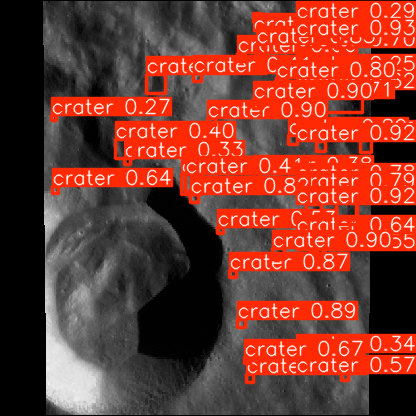


image 1/1 /content/drive/MyDrive/Major Project/Manual_dataset/crater_dataset/test/images/-8.514895020336349,-7.143014180499076,20.03407716829723,21.405958008134533.png: 512x512 123 craters, 11.1ms
Speed: 2.0ms preprocess, 11.1ms inference, 1.6ms postprocess per image at shape (1, 3, 512, 512)
Image 9: -8.514895020336349,-7.143014180499076,20.03407716829723,21.405958008134533.png
Craters detected: 123


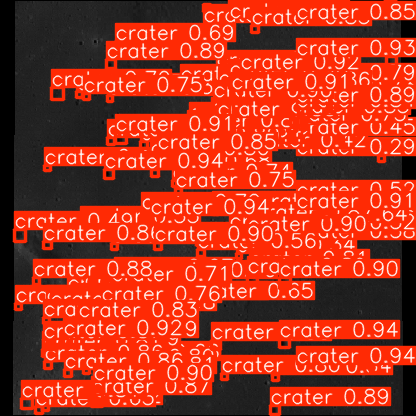


image 1/1 /content/drive/MyDrive/Major Project/Manual_dataset/crater_dataset/test/images/-75.73705617236449,-74.36517533252716,-47.188083983730884,-45.816203143893574.png: 512x512 44 craters, 11.0ms
Speed: 2.0ms preprocess, 11.0ms inference, 1.5ms postprocess per image at shape (1, 3, 512, 512)
Image 10: -75.73705617236449,-74.36517533252716,-47.188083983730884,-45.816203143893574.png
Craters detected: 44


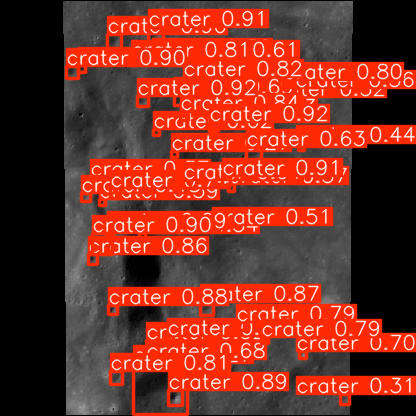

✅ All 10 images saved and displayed!


In [ ]:
from ultralytics import YOLO
from IPython.display import display
from PIL import Image
import glob
import os

# Load trained model
model = YOLO(
    "/content/drive/MyDrive/Major Project/Manual_dataset/My_Lunar_Models/crater_best.pt"
)

# Test folder
test_folder = "/content/drive/MyDrive/Major Project/Manual_dataset/crater_dataset/test/images"

# Get 10 images
images = (
    glob.glob(os.path.join(test_folder, "*.jpg")) +
    glob.glob(os.path.join(test_folder, "*.png"))
)[:10]

# Save folder
save_folder = "/content/drive/MyDrive/Major Project/Manual_dataset/My_Lunar_Models/10_detection_results"
os.makedirs(save_folder, exist_ok=True)

print("Total images:", len(images))

# Detect, save and display
for i, image_path in enumerate(images, 1):

    result = model.predict(
        source=image_path,
        conf=0.25,
        save=False
    )[0]

    # Create detected image
    detected_image = result.plot()

    # Save
    save_path = os.path.join(
        save_folder,
        f"crater_detection_{i}.jpg"
    )

    Image.fromarray(detected_image).save(save_path)

    # Display
    print(f"Image {i}: {os.path.basename(image_path)}")
    print(f"Craters detected: {len(result.boxes)}")

    display(Image.fromarray(detected_image))

print("✅ All 10 images saved and displayed!")

In [ ]:
BOULDER_PROJECT_NAME = "lunar_boulder_model"
BOULDER_YAML_PATH = "/content/drive/MyDrive/Major Project/Manual_dataset/boulder_dataset/boulder_data.yaml"

boulder_model, boulder_training_results = train_model(
    data_yaml_path=BOULDER_YAML_PATH,
    project_name=BOULDER_PROJECT_NAME,
    epochs=25,
    img_size=512,
    batch_size=8,
    pretrained_weights='yolov8s.pt'
)

print("\n\nBoth models have been trained successfully.")

--------------------------------------------------
Starting training for: lunar_boulder_model
Using data from: /content/drive/MyDrive/Major Project/Manual_dataset/boulder_dataset/boulder_data.yaml
Training for 25 epochs...
--------------------------------------------------
Ultralytics 8.4.126 🚀 Python-3.13.15 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=True, auto_augment=randaugment, batch=8, bgr=0.0, box=7.5, cache=False, cfg=None, channels_last=False, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, cls_remap=True, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=True, cutmix=0.0, data=/content/drive/MyDrive/Major Project/Manual_dataset/boulder_dataset/boulder_data.yaml, degrees=0.2, deterministic=True, device=0, dfl=1.5, dgrad=0.5, dis=6.0, distill_model=None, dlam=1.0, dlog=1.0, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=25, erasing=0.4, exist_ok=False, fliplr=0

In [ ]:
BEST_BOULDER_MODEL_PATH = f"/content/lunar_crater_runs/{BOULDER_PROJECT_NAME}/weights/best.pt"
DRIVE_BOULDER_MODEL_PATH = os.path.join(MODEL_SAVE_DIR, "boulder_best.pt")

if os.path.exists(BEST_BOULDER_MODEL_PATH):
    shutil.copy2(BEST_BOULDER_MODEL_PATH, DRIVE_BOULDER_MODEL_PATH)
    print(f"Boulder model successfully saved to: {DRIVE_BOULDER_MODEL_PATH}")
else:
    print(f"Could not find best boulder model at: {BEST_BOULDER_MODEL_PATH}")

print("\n\nAll processes complete. Both models have been saved to Google Drive.")

Boulder model successfully saved to: /content/drive/MyDrive/Major Project/Manual_dataset/My_Lunar_Models/boulder_best.pt


All processes complete. Both models have been saved to Google Drive.


Total images: 10

image 1/1 /content/drive/MyDrive/Major Project/Manual_dataset/boulder_dataset/test/images/Copy of -1.6554908211498391,-0.28360998131250864,-8.775420468286237,-7.403539628448936_aug_14.jpg: 512x512 19 boulders, 11.9ms
Speed: 2.3ms preprocess, 11.9ms inference, 2.2ms postprocess per image at shape (1, 3, 512, 512)
Image 1: Copy of -1.6554908211498391,-0.28360998131250864,-8.775420468286237,-7.403539628448936_aug_14.jpg
Craters detected: 19


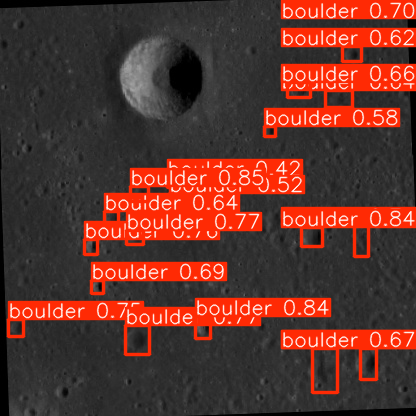


image 1/1 /content/drive/MyDrive/Major Project/Manual_dataset/boulder_dataset/test/images/Copy of -1.6554908211498391,-0.28360998131250864,-7.403539628448936,-6.03165878861162_aug_38.jpg: 512x512 20 boulders, 11.0ms
Speed: 2.1ms preprocess, 11.0ms inference, 1.6ms postprocess per image at shape (1, 3, 512, 512)
Image 2: Copy of -1.6554908211498391,-0.28360998131250864,-7.403539628448936,-6.03165878861162_aug_38.jpg
Craters detected: 20


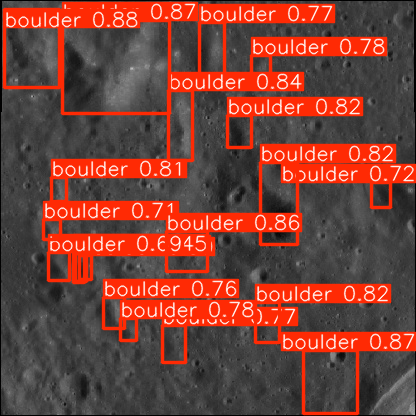


image 1/1 /content/drive/MyDrive/Major Project/Manual_dataset/boulder_dataset/test/images/Copy of -0.28360998131250864,1.0882708585247933,40.61228976585686,41.98417060569416_aug_12.jpg: 512x512 10 boulders, 11.1ms
Speed: 3.2ms preprocess, 11.1ms inference, 1.7ms postprocess per image at shape (1, 3, 512, 512)
Image 3: Copy of -0.28360998131250864,1.0882708585247933,40.61228976585686,41.98417060569416_aug_12.jpg
Craters detected: 10


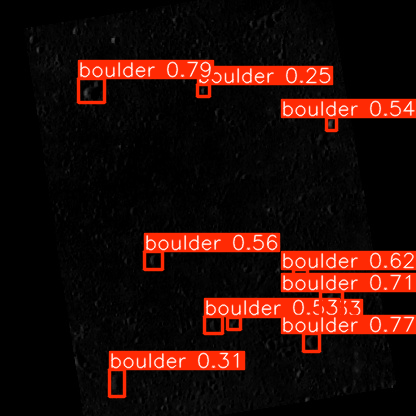


image 1/1 /content/drive/MyDrive/Major Project/Manual_dataset/boulder_dataset/test/images/Copy of -0.28360998131250864,1.0882708585247933,35.12476640650762,36.49664724634492_aug_7.jpg: 512x512 7 boulders, 11.1ms
Speed: 3.0ms preprocess, 11.1ms inference, 1.8ms postprocess per image at shape (1, 3, 512, 512)
Image 4: Copy of -0.28360998131250864,1.0882708585247933,35.12476640650762,36.49664724634492_aug_7.jpg
Craters detected: 7


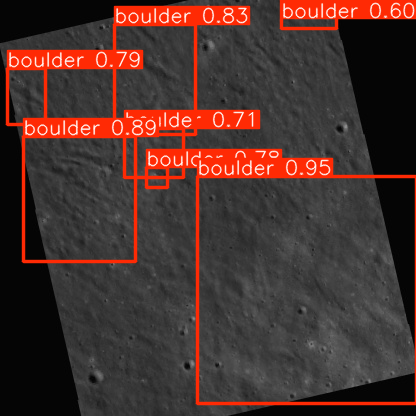


image 1/1 /content/drive/MyDrive/Major Project/Manual_dataset/boulder_dataset/test/images/Copy of -0.28360998131250864,1.0882708585247933,40.61228976585686,41.98417060569416_aug_9.jpg: 512x512 14 boulders, 11.9ms
Speed: 3.6ms preprocess, 11.9ms inference, 2.1ms postprocess per image at shape (1, 3, 512, 512)
Image 5: Copy of -0.28360998131250864,1.0882708585247933,40.61228976585686,41.98417060569416_aug_9.jpg
Craters detected: 14


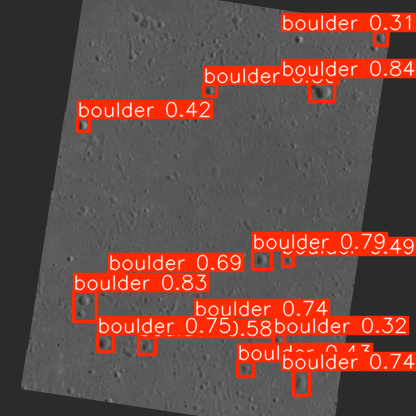


image 1/1 /content/drive/MyDrive/Major Project/Manual_dataset/boulder_dataset/test/images/Copy of -0.28360998131250864,1.0882708585247933,58.44674068374186,59.81862152357916_aug_47.jpg: 512x512 6 boulders, 11.0ms
Speed: 2.1ms preprocess, 11.0ms inference, 1.4ms postprocess per image at shape (1, 3, 512, 512)
Image 6: Copy of -0.28360998131250864,1.0882708585247933,58.44674068374186,59.81862152357916_aug_47.jpg
Craters detected: 6


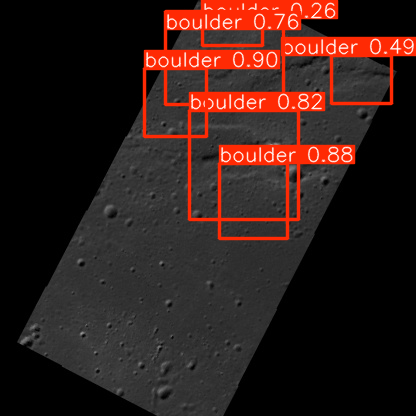


image 1/1 /content/drive/MyDrive/Major Project/Manual_dataset/boulder_dataset/test/images/Copy of -1.6554908211498391,-0.28360998131250864,-7.403539628448936,-6.03165878861162_aug_43.jpg: 512x512 17 boulders, 11.1ms
Speed: 2.1ms preprocess, 11.1ms inference, 1.4ms postprocess per image at shape (1, 3, 512, 512)
Image 7: Copy of -1.6554908211498391,-0.28360998131250864,-7.403539628448936,-6.03165878861162_aug_43.jpg
Craters detected: 17


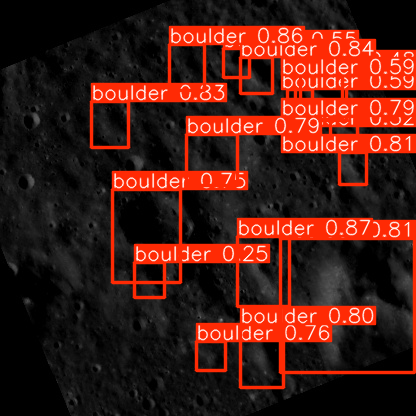


image 1/1 /content/drive/MyDrive/Major Project/Manual_dataset/boulder_dataset/test/images/Copy of -0.28360998131250864,1.0882708585247933,58.44674068374186,59.81862152357916_aug_2.jpg: 512x512 4 boulders, 11.0ms
Speed: 2.1ms preprocess, 11.0ms inference, 1.4ms postprocess per image at shape (1, 3, 512, 512)
Image 8: Copy of -0.28360998131250864,1.0882708585247933,58.44674068374186,59.81862152357916_aug_2.jpg
Craters detected: 4


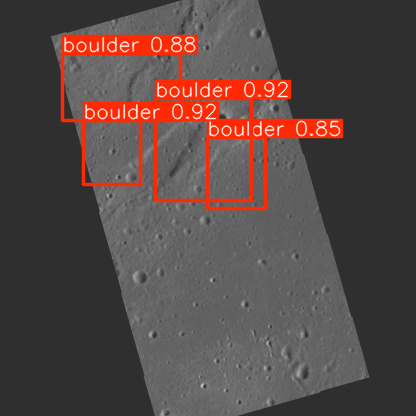


image 1/1 /content/drive/MyDrive/Major Project/Manual_dataset/boulder_dataset/test/images/Copy of -0.28360998131250864,1.0882708585247933,46.09981312520608,47.471693965043386_aug_46.jpg: 512x512 22 boulders, 12.5ms
Speed: 2.3ms preprocess, 12.5ms inference, 2.2ms postprocess per image at shape (1, 3, 512, 512)
Image 9: Copy of -0.28360998131250864,1.0882708585247933,46.09981312520608,47.471693965043386_aug_46.jpg
Craters detected: 22


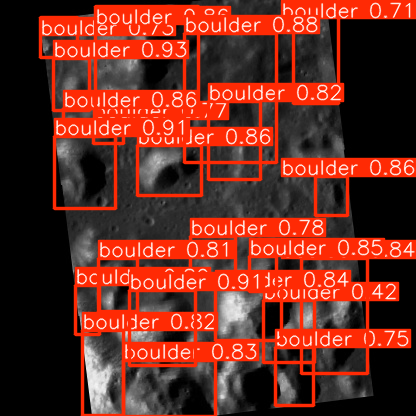


image 1/1 /content/drive/MyDrive/Major Project/Manual_dataset/boulder_dataset/test/images/Copy of -1.6554908211498391,-0.28360998131250864,-0.5441354292623967,0.8277454105749196_aug_2.jpg: 512x512 4 boulders, 11.0ms
Speed: 2.4ms preprocess, 11.0ms inference, 1.6ms postprocess per image at shape (1, 3, 512, 512)
Image 10: Copy of -1.6554908211498391,-0.28360998131250864,-0.5441354292623967,0.8277454105749196_aug_2.jpg
Craters detected: 4


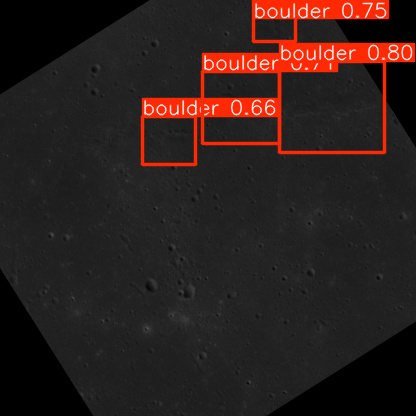

✅ All 10 images saved and displayed!


In [ ]:
from ultralytics import YOLO
from IPython.display import display
from PIL import Image
import glob
import os

# Load trained model
model = YOLO(
    "/content/drive/MyDrive/Major Project/Manual_dataset/My_Lunar_Models/boulder_best.pt"
)

# Test folder
test_folder = "/content/drive/MyDrive/Major Project/Manual_dataset/boulder_dataset/test/images"

# Get 10 images
images = (
    glob.glob(os.path.join(test_folder, "*.jpg")) +
    glob.glob(os.path.join(test_folder, "*.png"))
)[:10]

# Save folder
save_folder = "/content/drive/MyDrive/Major Project/Manual_dataset/My_Lunar_Models/10_detection_results"
os.makedirs(save_folder, exist_ok=True)

print("Total images:", len(images))

# Detect, save and display
for i, image_path in enumerate(images, 1):

    result = model.predict(
        source=image_path,
        conf=0.25,
        save=False
    )[0]

    # Create detected image
    detected_image = result.plot()

    # Save
    save_path = os.path.join(
        save_folder,
        f"crater_detection_{i}.jpg"
    )

    Image.fromarray(detected_image).save(save_path)

    # Display
    print(f"Image {i}: {os.path.basename(image_path)}")
    print(f"Craters detected: {len(result.boxes)}")

    display(Image.fromarray(detected_image))

print("✅ All 10 images saved and displayed!")

In [19]:
def plot_training_curves(results_path, model_name):
    """
    Plot training and validation metrics for a specific model run.

    Args:
        results_path (str): Path to the specific training run folder (e.g., 'runs/detect/lunar_crater_model').
        model_name (str): The name of the model for plot titles (e.g., 'Crater Model').
    """
    print(f"\n--- Generating plots for: {model_name} ---")

    metrics_csv = os.path.join(results_path, 'results.csv')
    if not os.path.exists(metrics_csv):
        print(f"No training metrics found at: {metrics_csv}")
        return

    # Read metrics
    metrics = np.loadtxt(metrics_csv, delimiter=",", skiprows=1)

    # Plot training curves
    plt.figure(figsize=(15, 10))
    plt.suptitle(f"Training Analysis for {model_name}", fontsize=16)

    # Plot loss curves
    plt.subplot(2, 2, 1)
    plt.plot(metrics[:, 0], metrics[:, 5], label='train_loss') # Updated column for box_loss
    plt.plot(metrics[:, 0], metrics[:, 8], label='val_loss') # Updated column for val/box_loss
    plt.title('Training and Validation Loss')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.legend()
    plt.grid(True)

    # Plot mAP metrics
    plt.subplot(2, 2, 2)
    plt.plot(metrics[:, 0], metrics[:, 3], label='mAP50(B)') # Updated column
    plt.plot(metrics[:, 0], metrics[:, 4], label='mAP50-95(B)') # Updated column
    plt.title('mAP Metrics (Validation)')
    plt.xlabel('Epoch')
    plt.ylabel('mAP')
    plt.legend()
    plt.grid(True)

    # Plot precision and recall
    plt.subplot(2, 2, 3)
    plt.plot(metrics[:, 0], metrics[:, 1], label='precision(B)') # Updated column
    plt.plot(metrics[:, 0], metrics[:, 2], label='recall(B)') # Updated column
    plt.title('Precision and Recall (Validation)')
    plt.xlabel('Epoch')
    plt.ylabel('Value')
    plt.legend()
    plt.grid(True)

    # Check for signs of overfitting
    train_loss = metrics[:, 5] # train/box_loss
    val_loss = metrics[:, 8]   # val/box_loss
    loss_diff = val_loss - train_loss

    plt.subplot(2, 2, 4)
    plt.plot(metrics[:, 0], loss_diff, label='val_loss - train_loss')
    plt.axhline(y=0, color='r', linestyle='--')
    plt.title('Overfitting Monitor')
    plt.xlabel('Epoch')
    plt.ylabel('Loss Difference')
    plt.legend()
    plt.grid(True)

    plt.tight_layout(rect=[0, 0.03, 1, 0.95])
    plt.show()

    # Analyze for overfitting
    if len(loss_diff) > 10 and np.mean(loss_diff[-10:]) > 0.1:  # Check last 10 epochs
        print(f"\nWARNING: Potential overfitting detected for {model_name}.")
    else:
        print(f"\nNo significant overfitting detected for {model_name}.")


In [ ]:
CRATER_RESULTS_PATH = "/content/lunar_crater_runs/lunar_crater_model"
BOULDER_RESULTS_PATH = "/content/lunar_crater_runs/lunar_boulder_model"



--- Generating plots for: Crater Model ---


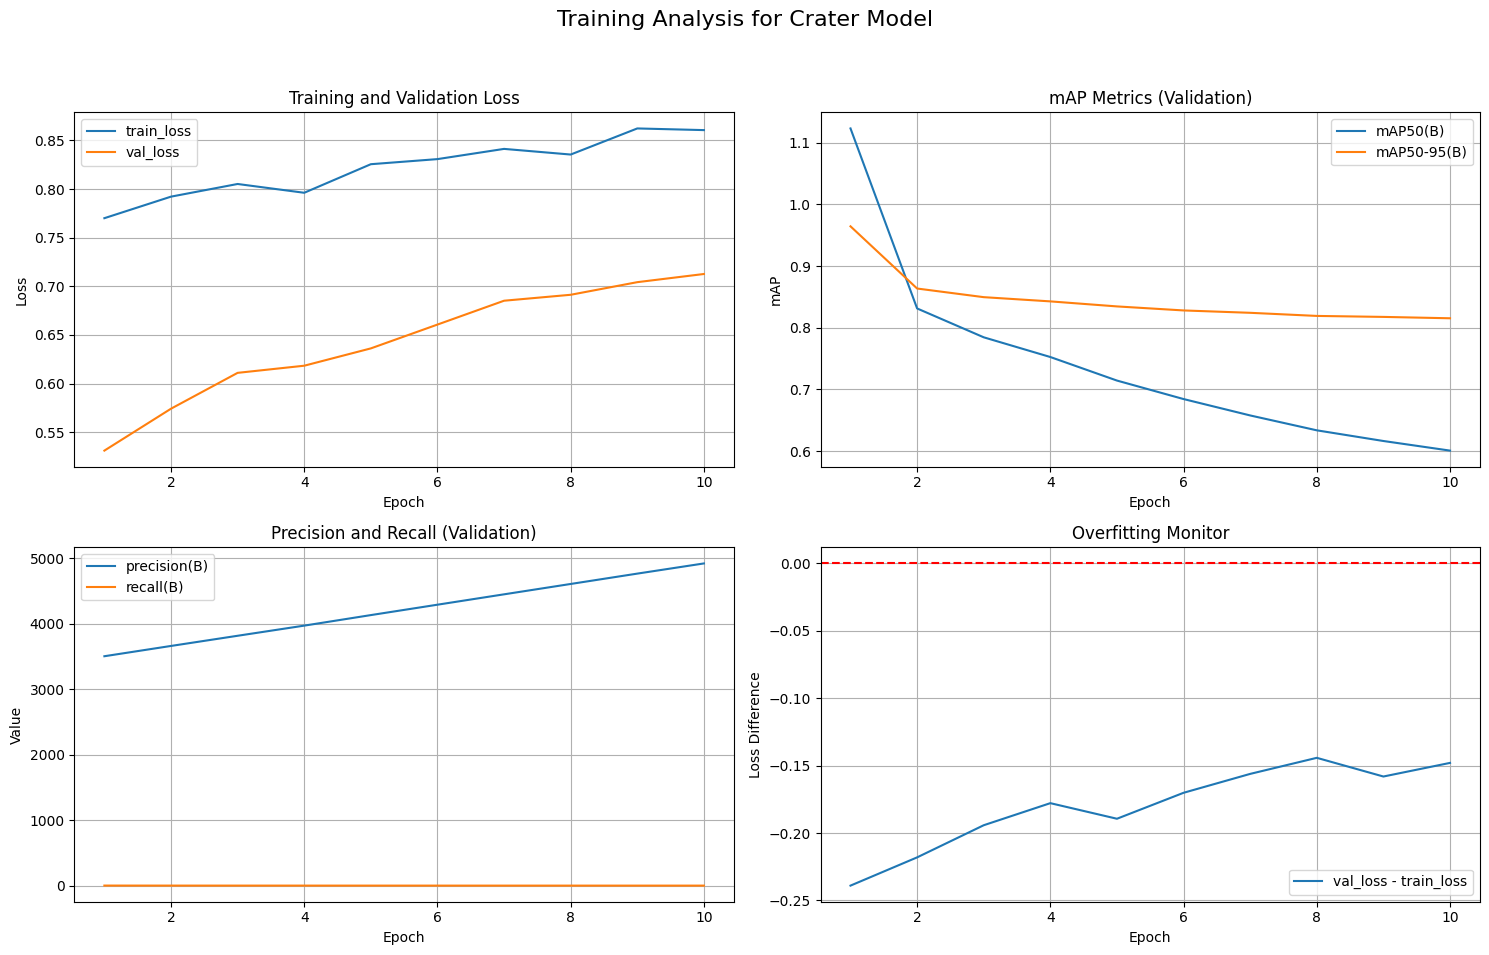


No significant overfitting detected for Crater Model.

--- Generating plots for: Boulder Model ---


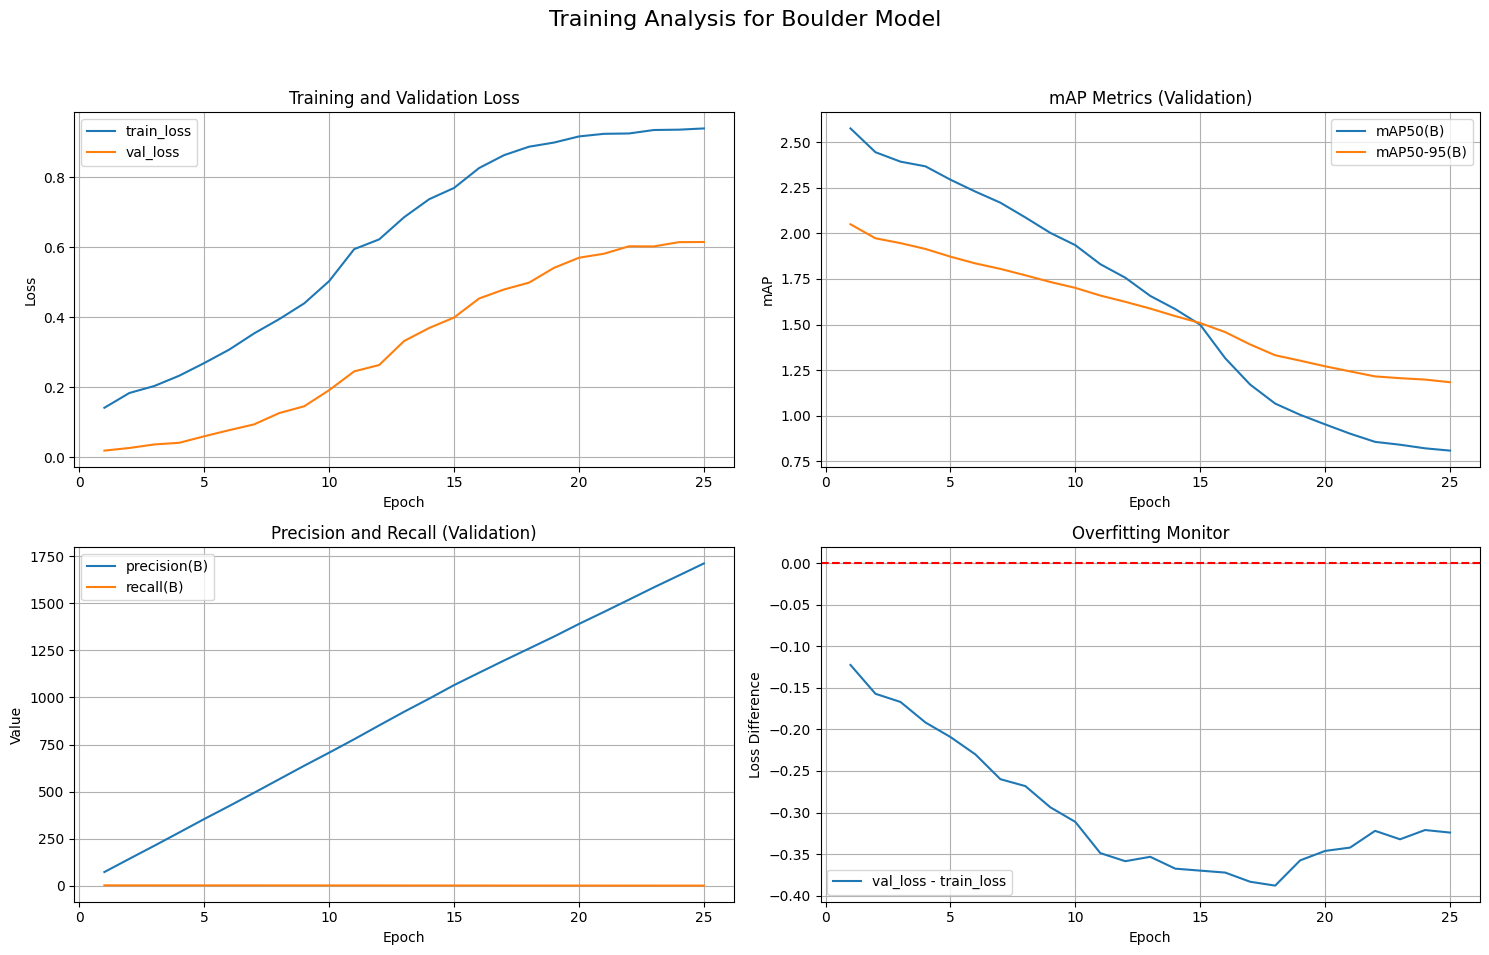


No significant overfitting detected for Boulder Model.


In [ ]:
plot_training_curves(CRATER_RESULTS_PATH, "Crater Model")
plot_training_curves(BOULDER_RESULTS_PATH, "Boulder Model")

In [20]:
def evaluate_model(model, data_yaml_path, model_name):
    """
    Evaluate a trained model on its validation set.
    """
    print(f"\n--- Evaluating {model_name} ---")
    results = model.val(data=data_yaml_path)
    return results


In [ ]:
DRIVE_MODEL_PATH = "/content/drive/MyDrive/Major Project/Manual_dataset/My_Lunar_Models"
DATASET_PATH = "/content/drive/MyDrive/Major Project/Manual_dataset/"

CRATER_MODEL_PATH = os.path.join(DRIVE_MODEL_PATH, "crater_best.pt")
BOULDER_MODEL_PATH = os.path.join(DRIVE_MODEL_PATH, "boulder_best.pt")

CRATER_YAML_PATH = "/content/drive/MyDrive/Major Project/Manual_dataset/crater_dataset/crater_data.yaml"
BOULDER_YAML_PATH = "/content/drive/MyDrive/Major Project/Manual_dataset/boulder_dataset/boulder_data.yaml"

# 2. Load your trained models
print("Loading trained models from Google Drive...")
crater_model = YOLO(CRATER_MODEL_PATH)
boulder_model = YOLO(BOULDER_MODEL_PATH)

# 3. Evaluate each model separately
crater_validation_results = evaluate_model(crater_model, CRATER_YAML_PATH, "Crater Model")
boulder_validation_results = evaluate_model(boulder_model, BOULDER_YAML_PATH, "Boulder Model")

print("\nEvaluation for both models is complete.")

Loading trained models from Google Drive...

--- Evaluating Crater Model ---
Ultralytics 8.4.126 🚀 Python-3.13.15 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
Model summary (fused): 73 layers, 11,125,971 parameters, 0 gradients, 28.4 GFLOPs
WARNING ⚠️ val: Slow image access detected (ping: 1.5±0.9 ms, read: 0.4±0.1 MB/s, size: 105.7 KB). Use local storage instead of remote/mounted storage for better performance. See https://docs.ultralytics.com/guides/model-training-tips
val: Scanning /content/drive/.shortcut-targets-by-id/19v7934lUj618pFhibLJDP4phnI9ebibo/Major Project/Manual_dataset/crater_dataset/val/labels.cache... 1535 images, 21 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 1535/1535 195.1Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 96/96 1.7it/s 57.9s
                   all       1535     167873      0.861      0.824      0.905      0.722
Speed: 1.0ms preprocess, 5.9ms inference, 0.0ms loss, 2.8ms postproces

In [5]:
def calculate_iou(box_a_yolo, box_b_yolo, img_shape):
    """
    Calculate the Intersection over Union (IoU) of two bounding boxes in YOLO format.
    """
    h, w = img_shape[:2]

    # Convert YOLO format [x_center, y_center, width, height] to [x_min, y_min, x_max, y_max]
    def yolo_to_xyxy(box):
        x_center, y_center, width, height = box
        x_min = (x_center - width / 2) * w
        y_min = (y_center - height / 2) * h
        x_max = (x_center + width / 2) * w
        y_max = (y_center + height / 2) * h
        return [x_min, y_min, x_max, y_max]

    box_a = yolo_to_xyxy(box_a_yolo)
    box_b = yolo_to_xyxy(box_b_yolo)

    # Determine the coordinates of the intersection rectangle
    x_left = max(box_a[0], box_b[0])
    y_top = max(box_a[1], box_b[1])
    x_right = min(box_a[2], box_b[2])
    y_bottom = min(box_a[3], box_b[3])

    if x_right < x_left or y_bottom < y_top:
        return 0.0

    intersection_area = (x_right - x_left) * (y_bottom - y_top)
    box_a_area = (box_a[2] - box_a[0]) * (box_a[3] - box_a[1])
    box_b_area = (box_b[2] - box_b[0]) * (box_b[3] - box_b[1])
    union_area = float(box_a_area + box_b_area - intersection_area)

    return intersection_area / union_area if union_area > 0 else 0.0


In [6]:
def predict_and_fuse(crater_model, boulder_model, image_path):
    """
    Runs prediction with two separate models and fuses the results based on
    confidence, IoU, and shape analysis.
    """
    # --- You can tune these parameters ---
    IOU_THRESHOLD = 0.4  # How much boxes must overlap to be considered a conflict
    BOULDER_CONFIDENCE_BOOST = 1.15 # Boost boulder confidence by 15% to balance it
    CRATER_ROUNDNESS_THRESHOLD = 0.8 # Aspect ratio (w/h) must be > this to be a likely crater
    # ---

    # Load the image once
    img = cv2.imread(image_path)
    if img is None:
        print("Error: Image not found.")
        return

    # Run predictions with both models
    crater_results = crater_model.predict(image_path, verbose=False)[0]
    boulder_results = boulder_model.predict(image_path, verbose=False)[0]

    # Get predictions as lists
    craters = [{'box': box.xywhn[0].tolist(), 'conf': box.conf[0].item(), 'cls': 0} for box in crater_results.boxes]
    boulders = [{'box': box.xywhn[0].tolist(), 'conf': box.conf[0].item(), 'cls': 1} for box in boulder_results.boxes]

    final_predictions = []

    # Keep track of boulder boxes that have been resolved in a conflict
    matched_boulder_indices = set()

    # --- Conflict Resolution ---
    # Iterate through each crater and find the best matching boulder
    for i, crater in enumerate(craters):
        best_iou = 0
        best_boulder_idx = -1

        for j, boulder in enumerate(boulders):
            iou = calculate_iou(crater['box'], boulder['box'], img.shape)
            if iou > best_iou:
                best_iou = iou
                best_boulder_idx = j

        # If a conflict is found (high overlap)
        if best_iou > IOU_THRESHOLD:
            matched_boulder_indices.add(best_boulder_idx)
            boulder = boulders[best_boulder_idx]

            # Apply confidence boost to boulder
            adjusted_boulder_conf = boulder['conf'] * BOULDER_CONFIDENCE_BOOST

            # Get aspect ratios (width/height)
            crater_w, crater_h = crater['box'][2], crater['box'][3]
            crater_aspect_ratio = min(crater_w / crater_h, crater_h / crater_w) # always <= 1

            # --- Decision Logic ---
            if crater_aspect_ratio > CRATER_ROUNDNESS_THRESHOLD:
                # The shape is very round, it's almost certainly a crater. Keep the crater.
                final_predictions.append(crater)
            elif crater['conf'] > adjusted_boulder_conf:
                # Shape is ambiguous, but crater confidence is significantly higher. Keep crater.
                final_predictions.append(crater)
            else:
                # The object is likely a boulder (either shape is irregular or confidence is higher).
                final_predictions.append(boulder)
        else:
            # No conflict, keep the crater
            final_predictions.append(crater)

    # Add all boulder predictions that were NOT part of a conflict
    for j, boulder in enumerate(boulders):
        if j not in matched_boulder_indices:
            final_predictions.append(boulder)

    # --- 3. DRAW FINAL RESULTS AND CREATE LISTS ---
    print("\n--- Final Fused Predictions ---")
    final_craters = []
    final_boulders = []

    display_img = img.copy()
    h, w, _ = display_img.shape

    CLASS_NAMES = {0: 'crater', 1: 'boulder'}
    COLORS = {0: (0, 255, 0), 1: (255, 200, 0)}

    for i, pred in enumerate(final_predictions):
        cls_id = pred['cls']

        # Add to numbered list
        if cls_id == 0:
            final_craters.append(pred)
        else:
            final_boulders.append(pred)

        # Draw bounding box
        x_c, y_c, width, height = pred['box']
        x1 = int((x_c - width/2) * w)
        y1 = int((y_c - height/2) * h)
        x2 = int((x_c + width/2) * w)
        y2 = int((y_c + height/2) * h)

        class_name = CLASS_NAMES[cls_id]
        color = COLORS[cls_id]
        conf = pred['conf']

        cv2.rectangle(display_img, (x1, y1), (x2, y2), color, 2)
        cv2.putText(display_img, f"{class_name} {conf:.2f}", (x1, y1 - 10), cv2.FONT_HERSHEY_SIMPLEX, 0.7, color, 2)

    # Display the final image
    im = Image.fromarray(cv2.cvtColor(display_img, cv2.COLOR_BGR2RGB))
    plt.figure(figsize=(12, 12))
    plt.imshow(im)
    plt.axis('off')
    plt.show()

    # Print the numbered lists
    print(f"\nFound {len(final_craters)} Craters:")
    for i, crater in enumerate(final_craters):
        print(f"  {i+1}: Confidence={crater['conf']:.2f}, BBox={crater['box']}")

    print(f"\nFound {len(final_boulders)} Boulders:")
    for i, boulder in enumerate(final_boulders):
        print(f"  {i+1}: Confidence={boulder['conf']:.2f}, BBox={boulder['box']}")


In [13]:
CRATER_MODEL_PATH = "/content/drive/MyDrive/Major Project/Manual_dataset/My_Lunar_Models/crater_best.pt"
BOULDER_MODEL_PATH = "/content/drive/MyDrive/Major Project/Manual_dataset/My_Lunar_Models/boulder_best.pt"


--- Final Fused Predictions ---


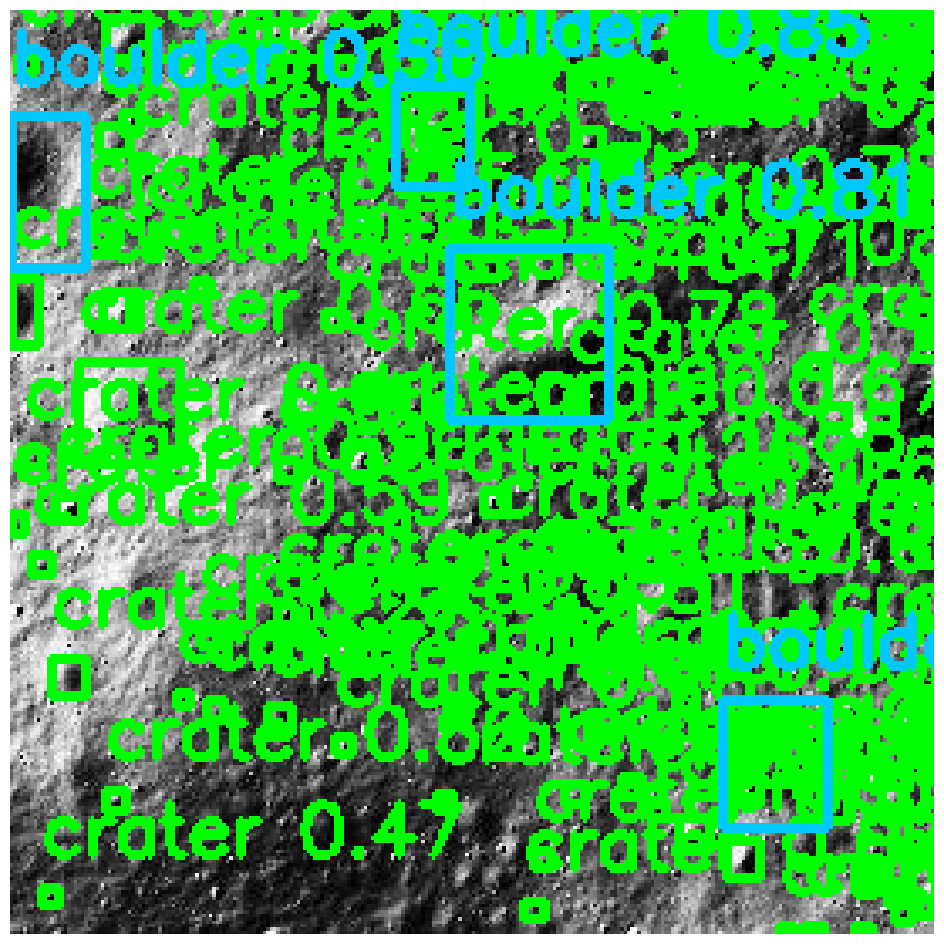


Found 105 Craters:
  1: Confidence=0.92, BBox=[0.9749729037284851, 0.8192808628082275, 0.022146739065647125, 0.021760258823633194]
  2: Confidence=0.92, BBox=[0.12896381318569183, 0.0339432992041111, 0.048600949347019196, 0.04835893213748932]
  3: Confidence=0.90, BBox=[0.06340594589710236, 0.5404751300811768, 0.027046920731663704, 0.027121271938085556]
  4: Confidence=0.90, BBox=[0.3793333172798157, 0.4859932065010071, 0.03248799592256546, 0.032222941517829895]
  5: Confidence=0.89, BBox=[0.13064594566822052, 0.12190309166908264, 0.019805017858743668, 0.0203496553003788]
  6: Confidence=0.89, BBox=[0.6865073442459106, 0.0867563933134079, 0.023156603798270226, 0.02328520454466343]
  7: Confidence=0.88, BBox=[0.6673189401626587, 0.060592733323574066, 0.022050898522138596, 0.022155553102493286]
  8: Confidence=0.88, BBox=[0.8729316592216492, 0.3849489390850067, 0.021006451919674873, 0.021153943613171577]
  9: Confidence=0.88, BBox=[0.5249534845352173, 0.5335826873779297, 0.0238530505448

In [21]:
TEST_IMAGE_PATH = "/content/drive/MyDrive/Major Project/dataset_bulk/ch2_ohr_nrp_20230820T0559124374_d_img_n18/74.340210-15.659790-32.jpg"
XML_FILE_PATH = '/content/drive/MyDrive/Major Project/dataset_bulk/ch2_ohr_ncp_20240316T2205464986_d_img_d18/ch2_ohr_ncp_20240316T2205464986_d_img_d18.xml'

crater_model = YOLO(CRATER_MODEL_PATH)
boulder_model = YOLO(BOULDER_MODEL_PATH)

# 4. Run the fusion prediction
predict_and_fuse(crater_model, boulder_model, TEST_IMAGE_PATH)

In [7]:
import cv2
import xml.etree.ElementTree as ET
import numpy as np
import math
from PIL import Image
import pandas as pd

In [8]:

def find_key_recursively(element, target_key):
    """
    Recursively searches a nested dictionary or list for a specific key.
    """
    if isinstance(element, dict):
        if target_key in element:
            return element[target_key]
        for key, value in element.items():
            result = find_key_recursively(value, target_key)
            if result is not None:
                return result
    elif isinstance(element, list):
        for item in element:
            result = find_key_recursively(item, target_key)
            if result is not None:
                return result
    return None

def extract_pixel_resolution(xml_path):
    """
    Parses an XML file and specifically finds the value of the 'isda:pixel_resolution' tag.
    """
    try:
        with open(xml_path, 'r') as f:
            data_dict = xmltodict.parse(f.read())
        resolution_object = find_key_recursively(data_dict, 'isda:pixel_resolution')
        if resolution_object and '#text' in resolution_object:
            return float(resolution_object['#text'])
        else:
            print("Warning: 'isda:pixel_resolution' tag not found in XML.")
            return None
    except Exception as e:
        print(f"An error occurred reading pixel resolution: {e}")
        return None

def extract_sun_elevation(xml_path):
    """
    Parses an XML file to find sun elevation. It first looks for the direct
    'isda:sun_elevation' tag. If not found, it looks for 'isda:solar_incidence'
    and calculates the elevation from it.
    """
    try:
        with open(xml_path, 'r') as f:
            data_dict = xmltodict.parse(f.read())

        # First, try to find the direct elevation tag
        elevation_obj = find_key_recursively(data_dict, 'isda:sun_elevation')
        if elevation_obj and '#text' in elevation_obj:
            return float(elevation_obj['#text'])

        # If not found, try to find the incidence angle and convert it
        incidence_obj = find_key_recursively(data_dict, 'isda:solar_incidence')
        if incidence_obj and '#text' in incidence_obj:
            incidence_angle = float(incidence_obj['#text'])
            return 90.0 - incidence_angle

        print("Warning: Neither sun elevation nor incidence angle found in XML.")
        return None
    except Exception as e:
        print(f"An error occurred reading sun angle: {e}")
        return None


In [9]:
def measure_shadow_length(crop_image):
    """
    Measures the length of a shadow in a cropped image using OpenCV.
    Improved to handle angled shadows more accurately.
    """
    if crop_image.size == 0:
        return 0

    gray = cv2.cvtColor(crop_image, cv2.COLOR_BGR2GRAY)
    blurred = cv2.GaussianBlur(gray, (5, 5), 0)
    shadow_mask = cv2.adaptiveThreshold(blurred, 255, cv2.ADAPTIVE_THRESH_MEAN_C,
                                        cv2.THRESH_BINARY_INV, 21, 5)
    contours, _ = cv2.findContours(shadow_mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

    if not contours:
        return 0

    largest_contour = max(contours, key=cv2.contourArea)

    # Use minAreaRect to get a rotated bounding box, which is more accurate for angled shadows
    rect = cv2.minAreaRect(largest_contour)
    (width, height) = rect[1]

    # Return the longest dimension of this rotated rectangle
    return max(width, height)



In [10]:

def analyze_and_display_results(crater_model, boulder_model, image_path, metadata_path):
    """
    Orchestrates the full process and returns a structured pandas DataFrame and an annotated image.
    """
    image = cv2.imread(image_path)
    if image is None:
        print(f"Error: Failed to load image at {image_path}")
        return None, None

    # Use the new, robust metadata functions
    sun_elevation = extract_sun_elevation(metadata_path)
    image_scale = extract_pixel_resolution(metadata_path)

    if sun_elevation is None or image_scale is None:
        print(f"Skipping analysis for {os.path.basename(image_path)} due to missing metadata.")
        return None, None

    print(f"Image Metadata | Scale: {image_scale} m/pixel | Sun Elevation: {sun_elevation:.2f}°")

    # Run predictions
    crater_results = crater_model.predict(image_path, verbose=False)[0]
    boulder_results = boulder_model.predict(image_path, verbose=False)[0]

    results_list = []

    # Process crater detections
    for box in crater_results.boxes:
        x1, y1, x2, y2 = map(int, box.xyxy[0].tolist())
        crop = image[y1:y2, x1:x2]
        shadow_pixels = measure_shadow_length(crop)
        diameter_meters = (x2 - x1) * image_scale
        method = "Shadow Measurement" if shadow_pixels > 5 else "Estimated (D-d Ratio)"
        depth_meters = (shadow_pixels * image_scale * math.tan(math.radians(sun_elevation))) if method == "Shadow Measurement" else (diameter_meters * 0.2)
        results_list.append({'class': 'Crater', 'confidence': box.conf[0].item(), 'depth(KM)': depth_meters, 'height(KM)': None, 'method': method})

    # Process boulder detections
    for box in boulder_results.boxes:
        x1, y1, x2, y2 = map(int, box.xyxy[0].tolist())
        crop = image[y1:y2, x1:x2]
        shadow_pixels = measure_shadow_length(crop)
        width_meters = (x2 - x1) * image_scale
        method = "Shadow Measurement" if shadow_pixels > 3 else "Estimated (H-W Ratio)"
        height_meters = (shadow_pixels * image_scale * math.tan(math.radians(sun_elevation))) if method == "Shadow Measurement" else (width_meters * 0.5)
        results_list.append({'class': 'Boulder', 'confidence': box.conf[0].item(), 'depth(KM)': None, 'height(KM)': height_meters, 'method': method})

    results_df = pd.DataFrame(results_list)

    # --- Create visualization ---
    display_image = image.copy()
    all_boxes = crater_results.boxes.xyxy.tolist() + boulder_results.boxes.xyxy.tolist()

    for i, row in results_df.iterrows():
        # Get original bbox coordinates for drawing
        x1, y1, x2, y2 = map(int, all_boxes[i])

        if row['class'] == 'Crater':
            color, text = (0, 255, 0), f"Crater #{i+1} | Depth: {row['depth(KM)']:.2f}m ({row['method']})"
        else:
            color, text = (255, 200, 0), f"Boulder #{i+1} | Height: {row['height(KM)']:.2f}m ({row['method']})"

        cv2.rectangle(display_image, (x1, y1), (x2, y2), color, 2)
        cv2.putText(display_image, text, (x1, y1 - 10), cv2.FONT_HERSHEY_SIMPLEX, 0.8, color, 2)

    return results_df, display_image


In [11]:
CRATER_MODEL_PATH = "/content/drive/MyDrive/Major Project/Manual_dataset/My_Lunar_Models/crater_best.pt"
BOULDER_MODEL_PATH = "/content/drive/MyDrive/Major Project/Manual_dataset/My_Lunar_Models/boulder_best.pt"
CRATER_DB_PATH = "/content/drive/MyDrive/Major Project/Lunar_Impact_Crater_Database_v08Sep2015.xls"


In [22]:
print("Loading trained models from Google Drive...")
crater_model = YOLO(CRATER_MODEL_PATH)
boulder_model = YOLO(BOULDER_MODEL_PATH)


Loading trained models from Google Drive...


Image Metadata | Scale: 0.19 m/pixel | Sun Elevation: 2.32°

--- Analysis Results Table ---
       class  confidence  depth(KM)  height(KM)                 method
0     Crater        0.92       0.23         NaN  Estimated (D-d Ratio)
1     Crater        0.92       0.09         NaN     Shadow Measurement
2     Crater        0.90       0.30         NaN  Estimated (D-d Ratio)
3     Crater        0.90       0.05         NaN     Shadow Measurement
4     Crater        0.89       0.19         NaN  Estimated (D-d Ratio)
..       ...         ...        ...         ...                    ...
107  Boulder        0.80        NaN        0.23     Shadow Measurement
108  Boulder        0.77        NaN        0.16     Shadow Measurement
109  Boulder        0.66        NaN        0.13     Shadow Measurement
110  Boulder        0.50        NaN        0.24     Shadow Measurement
111  Boulder        0.35        NaN        0.17     Shadow Measurement

[112 rows x 5 columns]

--- Annotated Image ---


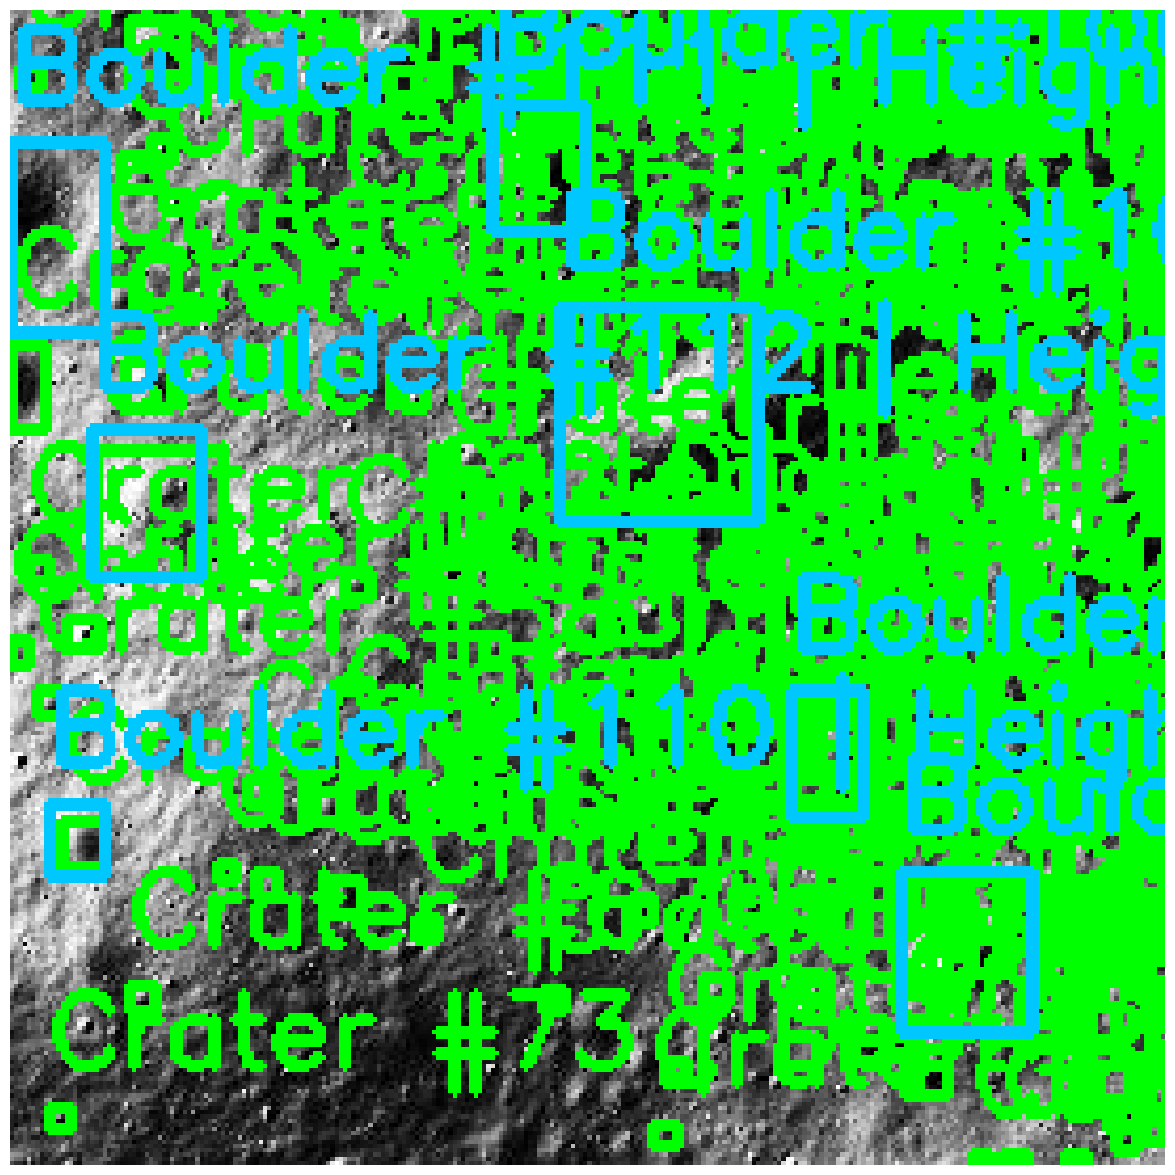

In [23]:
TEST_IMAGE_PATH = "/content/drive/MyDrive/Major Project/dataset_bulk/ch2_ohr_nrp_20230820T0559124374_d_img_n18/74.340210-15.659790-32.jpg"
XML_FILE_PATH = '/content/drive/MyDrive/Major Project/dataset_bulk/ch2_ohr_ncp_20240316T2205464986_d_img_d18/ch2_ohr_ncp_20240316T2205464986_d_img_d18.xml'


final_results_df, final_image = analyze_and_display_results(
    crater_model,
    boulder_model,
    TEST_IMAGE_PATH,
    XML_FILE_PATH
)

# 4. Display the final results table and image
if final_results_df is not None:
    print("\n--- Analysis Results Table ---")
    print(final_results_df[['class', 'confidence', 'depth(KM)', 'height(KM)', 'method']].round(2))

    print("\n--- Annotated Image ---")
    final_image_rgb = cv2.cvtColor(final_image, cv2.COLOR_BGR2RGB)
    plt.figure(figsize=(15, 15))
    plt.imshow(final_image_rgb)
    plt.axis('off')
    plt.show()

In [24]:
!pip install tensorflow

In [25]:
from tensorflow.keras.applications.mobilenet_v2 import MobileNetV2, preprocess_input, decode_predictions
from tensorflow.keras.preprocessing import image as keras_image
import cv2
import numpy as np


In [26]:

def is_image_clear(image_path, blur_threshold=100.0):
    """
    Checks if an image is too blurry or noisy using Laplacian variance.
    Returns True if the image is clear, False otherwise.
    """
    try:
        img = cv2.imread(image_path)
        if img is None: return False

        gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
        laplacian_var = cv2.Laplacian(gray, cv2.CV_64F).var()

        print("Image Clarity Analysis:")
        print(f"  - Laplacian Variance: {laplacian_var:.2f} (Threshold: > {blur_threshold})")

        if laplacian_var < blur_threshold:
            print(f"\n[Validation FAILED] Reason: Image is too blurry or noisy.")
            return False

        return True
    except Exception as e:
        print(f"An error occurred during clarity analysis: {e}")
        return False


In [27]:
def validate_content_with_color(image_path, saturation_threshold=25):
    """
    Checks if an image is likely a lunar surface by analyzing its color saturation.
    A low saturation suggests a grayscale or near-grayscale image.
    Returns True if saturation is low, False otherwise.
    """
    try:
        img = cv2.imread(image_path)
        if img is None: return False

        # Convert image to Hue, Saturation, Value (HSV) color space
        hsv = cv2.cvtColor(img, cv2.COLOR_BGR2HSV)

        # Calculate the average saturation value (the 'S' channel)
        mean_saturation = hsv[:, :, 1].mean()

        print("\nImage Content Analysis (Color):")
        print(f"  - Average Saturation: {mean_saturation:.2f} (Threshold: < {saturation_threshold})")

        if mean_saturation < saturation_threshold:
            return True
        else:
            print(f"\n[Validation FAILED] Reason: Image appears to be too colorful for a lunar surface.")
            return False
    except Exception as e:
        print(f"An error occurred during color analysis: {e}")
        return False

--- Starting Image Validation ---
Image Clarity Analysis:
  - Laplacian Variance: 11607.35 (Threshold: > 100.0)

Image Content Analysis (Color):
  - Average Saturation: 0.00 (Threshold: < 25)

[Validation SUCCESS] Image is valid. Proceeding to full analysis...
Image Metadata | Scale: 0.19 m/pixel | Sun Elevation: 2.32°

--- Analysis Results Table ---
       class  confidence  depth(KM)  height(KM)                 method
0     Crater        0.92       0.23         NaN  Estimated (D-d Ratio)
1     Crater        0.92       0.09         NaN     Shadow Measurement
2     Crater        0.90       0.30         NaN  Estimated (D-d Ratio)
3     Crater        0.90       0.05         NaN     Shadow Measurement
4     Crater        0.89       0.19         NaN  Estimated (D-d Ratio)
..       ...         ...        ...         ...                    ...
107  Boulder        0.80        NaN        0.23     Shadow Measurement
108  Boulder        0.77        NaN        0.16     Shadow Measurement
109  Bou

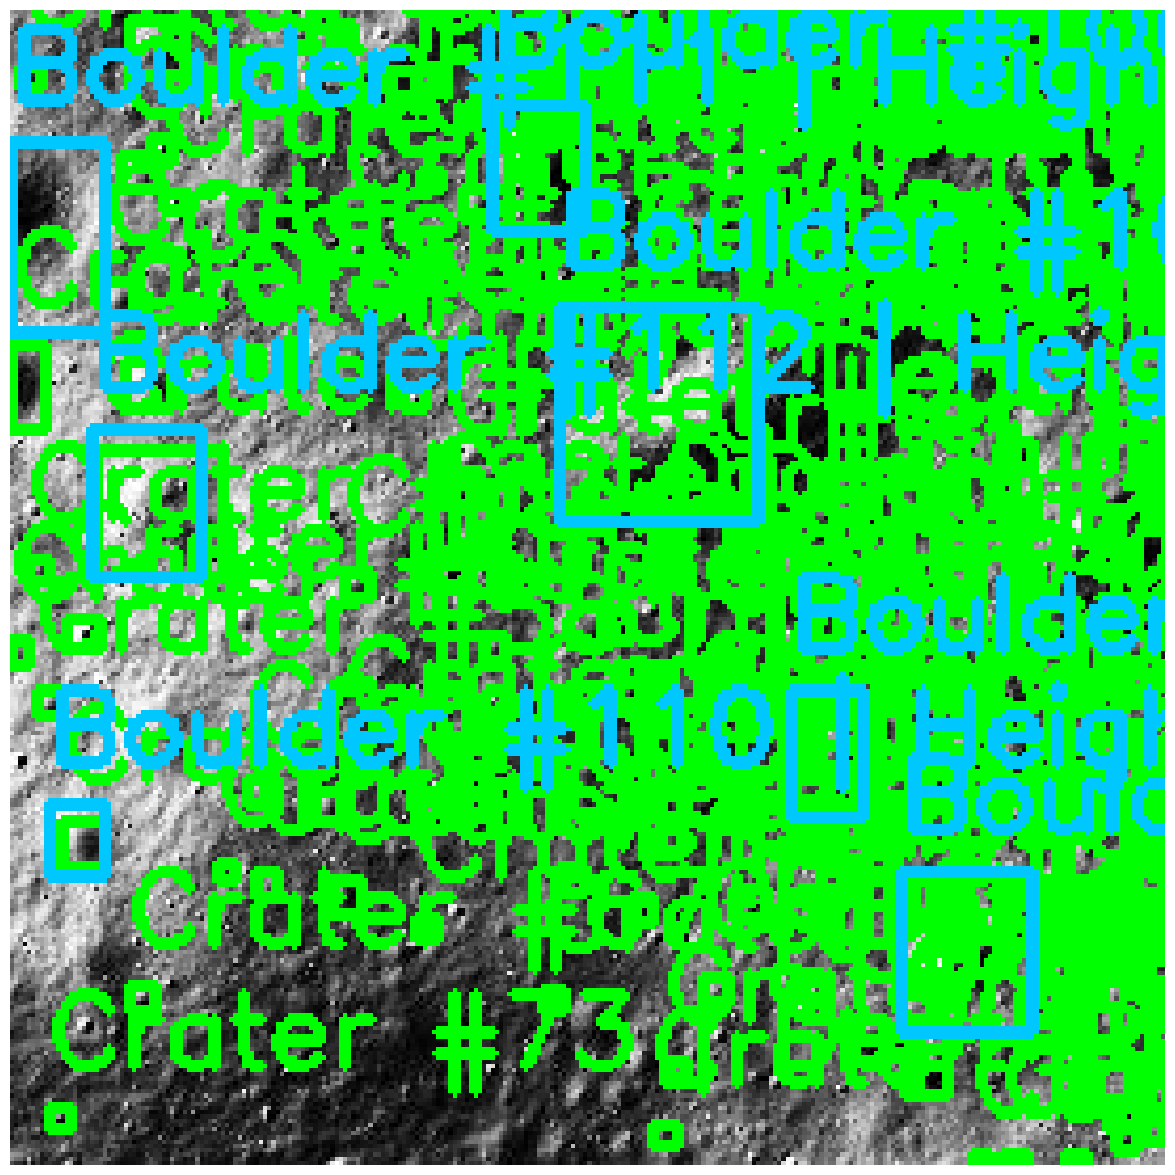

In [28]:
# 3. Run the validation checks
print("--- Starting Image Validation ---")
is_clear = is_image_clear(TEST_IMAGE_PATH)
is_valid_content = False
if is_clear:
    # Only check content if the image is clear
    is_valid_content = validate_content_with_color(TEST_IMAGE_PATH)

# 4. Proceed to the main analysis only if both checks pass
if is_clear and is_valid_content:
    print("\n[Validation SUCCESS] Image is valid. Proceeding to full analysis...")

    # This is where you would call your main analysis function:
    final_results_df, final_image = analyze_and_display_results(
         crater_model,
         boulder_model,
         TEST_IMAGE_PATH,
         XML_FILE_PATH
     )
    if final_results_df is not None:
      print("\n--- Analysis Results Table ---")
      print(final_results_df[['class', 'confidence', 'depth(KM)', 'height(KM)', 'method']].round(2))

      print("\n--- Annotated Image ---")
      final_image_rgb = cv2.cvtColor(final_image, cv2.COLOR_BGR2RGB)
      plt.figure(figsize=(15, 15))
      plt.imshow(final_image_rgb)
      plt.axis('off')
      plt.show()
else:
    print("\n--- Analysis Halted Due to Validation Failure ---")
    print("Please upload a different image.")

In [29]:
# Install required libraries
!pip install flask flask-cors
!npm install -g localtunnel
!pip install flask flask-cors flask_cloudflared ultralytics
!pip install flask flask-cors flask_cloudflared ultralytics pandas xmltodict

⠙⠹⠸⠼⠴⠦⠧⠇⠏⠋⠙⠹⠸⠼⠴⠦⠧⠇⠏⠋⠙⠹⠸⠼⠴⠦
added 22 packages in 3s
⠦
⠦3 packages are looking for funding
⠦  run `npm fund` for details
⠦Requirement already satisfied: flask in /usr/local/lib/python3.13/dist-packages (3.1.3)


In [30]:
import os
import cv2
import math
import pandas as pd
import xmltodict
import re
import base64
from flask import Flask, request, jsonify
from flask_cors import CORS
from flask_cloudflared import run_with_cloudflared
from ultralytics import YOLO


In [ ]:
from flask import Flask, request, jsonify
from flask_cors import CORS
from ultralytics import YOLO
import os
import cv2
import base64

app = Flask(__name__)
CORS(app)

# Start Cloudflare tunnel
run_with_cloudflared(app)

# --------------------------------------------------
# UPLOAD FOLDER
# --------------------------------------------------

UPLOAD_FOLDER = '/content/drive/MyDrive/Major Project/uploads'
os.makedirs(UPLOAD_FOLDER, exist_ok=True)

# --------------------------------------------------
# FIXED XML METADATA
# --------------------------------------------------

XML_PATH = "/content/drive/MyDrive/Major Project/metadata/lunar_metadata.xml"

if os.path.exists(XML_PATH):
    print("✅ XML metadata found:")
    print(XML_PATH)
else:
    print("❌ XML metadata not found!")

# --------------------------------------------------
# LOAD AI MODELS
# --------------------------------------------------

print("Loading AI models...")

CRATER_MODEL_PATH = "/content/drive/MyDrive/Major Project/Manual_dataset/My_Lunar_Models/crater_best.pt"

BOULDER_MODEL_PATH = "/content/drive/MyDrive/Major Project/Manual_dataset/My_Lunar_Models/boulder_best.pt"

crater_model = YOLO(CRATER_MODEL_PATH)
boulder_model = YOLO(BOULDER_MODEL_PATH)

print("✅ Models loaded successfully.")

# --------------------------------------------------
# ANALYZE API
# --------------------------------------------------

@app.route('/analyze', methods=['POST'])
def analyze_image_endpoint():

    try:

        # ------------------------------------------
        # ONLY IMAGE IS REQUIRED NOW
        # ------------------------------------------

        if 'image' not in request.files:
            return jsonify({
                'error': 'Image file is required'
            }), 400

        image_file = request.files['image']

        if image_file.filename == '':
            return jsonify({
                'error': 'No image selected'
            }), 400

        # ------------------------------------------
        # CHECK FIXED XML
        # ------------------------------------------

        if not os.path.exists(XML_PATH):
            return jsonify({
                'error': 'Fixed XML metadata file not found'
            }), 500

        # ------------------------------------------
        # SAVE IMAGE
        # ------------------------------------------

        image_path = os.path.join(
            UPLOAD_FOLDER,
            image_file.filename
        )

        image_file.save(image_path)

        print("📷 Image received:", image_file.filename)
        print("📄 Using XML:", XML_PATH)

        # ------------------------------------------
        # RUN YOUR EXISTING ANALYSIS FUNCTION
        # ------------------------------------------

        results_df, annotated_image = analyze_and_display_results(
            crater_model,
            boulder_model,
            image_path,
            XML_PATH
        )

        # ------------------------------------------
        # REMOVE UPLOADED IMAGE
        # ------------------------------------------

        if os.path.exists(image_path):
            os.remove(image_path)

        # ------------------------------------------
        # CHECK RESULT
        # ------------------------------------------

        if results_df is None:
            return jsonify({
                'error': 'Analysis failed. Check metadata or image file.'
            }), 500

        # ------------------------------------------
        # CONVERT ANNOTATED IMAGE TO BASE64
        # ------------------------------------------

        _, buffer = cv2.imencode(
            '.jpg',
            annotated_image
        )

        image_base64 = base64.b64encode(
            buffer
        ).decode('utf-8')

        # ------------------------------------------
        # CONVERT RESULTS TO JSON
        # ------------------------------------------

        results_json = results_df.to_json(
            orient='records'
        )

        # ------------------------------------------
        # SEND RESULT TO FRONTEND
        # ------------------------------------------

        return jsonify({
            'results_table': results_json,
            'annotated_image':
                f"data:image/jpeg;base64,{image_base64}"
        })

    except Exception as e:

        print("❌ Analysis error:", str(e))

        return jsonify({
            'error': str(e)
        }), 500


# --------------------------------------------------
# RUN FLASK SERVER
# --------------------------------------------------

print("🚀 Starting Lunar Terrain AI backend...")

app.run(
    host='0.0.0.0',
    port=5001
)

✅ XML metadata found:
/content/drive/MyDrive/Major Project/metadata/lunar_metadata.xml
Loading AI models...
✅ Models loaded successfully.
🚀 Starting Lunar Terrain AI backend...
 * Starting Cloudflared tunnel...
 * Serving Flask app '__main__'
 * Debug mode: off


INFO:werkzeug:WARNING: This is a development server. Do not use it in a production deployment. Use a production WSGI server instead.
 * Running on all addresses (0.0.0.0)
 * Running on http://127.0.0.1:5001
 * Running on http://172.28.0.12:5001
INFO:werkzeug:Press CTRL+C to quit


 * Downloading cloudflared for Linux x86_64...


 * Downloading:   0%|          | 0.00/38.3M [00:00<?, ?B/s]

 * Running on https://chassis-headers-how-thy.trycloudflare.com
 * Traffic stats available on http://127.0.0.1:8125/metrics
📷 Image received: 87.684105-2.315895-15.jpg
📄 Using XML: /content/drive/MyDrive/Major Project/metadata/lunar_metadata.xml
Image Metadata | Scale: 0.19 m/pixel | Sun Elevation: 2.32°


INFO:werkzeug:127.0.0.1 - - [05/Oct/2026 15:29:09] "POST /analyze HTTP/1.1" 200 -
INFO:werkzeug:127.0.0.1 - - [05/Oct/2026 15:29:28] "POST /analyze HTTP/1.1" 200 -


📷 Image received: 87.684105-2.315895-32.jpg
📄 Using XML: /content/drive/MyDrive/Major Project/metadata/lunar_metadata.xml
Image Metadata | Scale: 0.19 m/pixel | Sun Elevation: 2.32°


INFO:werkzeug:127.0.0.1 - - [05/Oct/2026 15:30:09] "POST /analyze HTTP/1.1" 200 -


📷 Image received: 74.340210-15.659790-32 (1).jpg
📄 Using XML: /content/drive/MyDrive/Major Project/metadata/lunar_metadata.xml
Image Metadata | Scale: 0.19 m/pixel | Sun Elevation: 2.32°
